# EDA



In [1]:
#montar drive y definir ruta
from google.colab import drive
drive.mount("/content/drive")

ruta = "/content/drive/Shared drives/ETL_second_delivery/"

Mounted at /content/drive


In [2]:
#instalar sweetviz para facilitar el EDA
!pip install -q sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 73.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
# Verificar si el join de fecha funciona
df_fact_test = pd.read_csv(ruta + "tf_fact.csv")
df_fecha_test = pd.read_csv(ruta + "tf_fecha.csv")

print("date_id sample:", df_fact_test["date_id"].value_counts().head())
print("dim_fecha id sample:", df_fecha_test["id"].value_counts().head())

# Ver cuántos coinciden
match = df_fact_test["date_id"].isin(df_fecha_test["id"])
print(f"date_id que SÍ hacen match: {match.sum()} / {len(df_fact_test)}")

date_id sample: date_id
346    221
345    221
344    221
343    221
342    221
Name: count, dtype: int64
dim_fecha id sample: id
346    1
1      1
2      1
3      1
4      1
Name: count, dtype: int64
date_id que SÍ hacen match: 66320 / 66320


-Aunque si no se tiene el contexto completo de como se hizo la union en la entrega 1 y 2 los resultados podrian parecer un error, no es asi, ya que representan registros distitno correspondientes a un mismo dia.
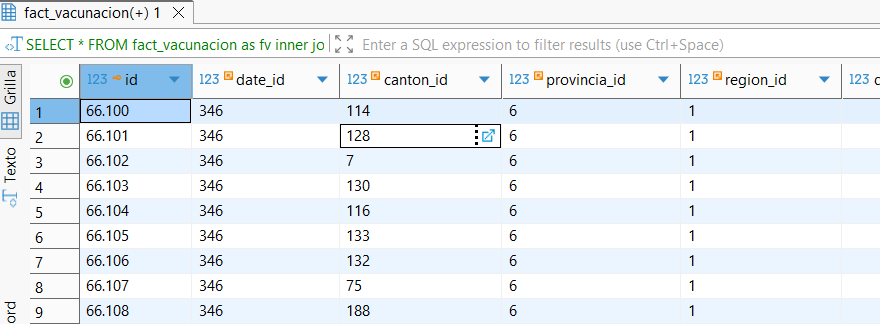

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from sweetviz import FeatureConfig
import warnings
warnings.filterwarnings("ignore")

#cargar los datasets transformados
df_fact   = pd.read_csv(ruta + "tf_fact.csv")
df_covid  = pd.read_csv(ruta + "tf_covid.csv")
df_uhc    = pd.read_csv(ruta + "tf_uhc.csv")
df_merged = pd.read_csv(ruta + "tf_merged.csv")

print()
for nombre, df in [("tf_fact", df_fact), ("tf_covid", df_covid),
                   ("tf_uhc", df_uhc), ("tf_merged", df_merged)]:
    print(f"{nombre:<12}: {df.shape[0]:>8,} filas  x  {df.shape[1]:>3} columnas")


tf_fact     :   66,320 filas  x   12 columnas
tf_covid    :    1,143 filas  x    5 columnas
tf_uhc      :       24 filas  x    2 columnas
tf_merged   :        1 filas  x    9 columnas


---
##Calidad de los datos



In [5]:
# Tabla resumen de calidad para los 4 datasets
resumen = []
for nombre, df in [("tf_fact", df_fact), ("tf_covid", df_covid),
                   ("tf_uhc", df_uhc), ("tf_merged", df_merged)]:
    nulos_total = df.isnull().sum().sum()
    cols_con_nulos = (df.isnull().sum() > 0).sum()
    resumen.append({
        "dataset"         : nombre,
        "filas"           : len(df),
        "columnas"        : df.shape[1],
        "nulos_total"     : nulos_total,
        "cols_con_nulos"  : cols_con_nulos,
        "duplicados"      : df.duplicated().sum(),
        "tipos"           : df.dtypes.value_counts().to_dict()
    })

df_quality = pd.DataFrame(resumen).drop(columns=["tipos"])
print("Resumen de calidad")
print(df_quality.to_string(index=False))

print("\n Nulos por columna ")
for nombre, df in [("tf_fact", df_fact), ("tf_covid", df_covid),
                   ("tf_uhc", df_uhc), ("tf_merged", df_merged)]:
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) > 0:
        print(f"\n[{nombre}]")
        for col, n in nulos.items():
            print(f"  {col}: {n} nulos ({100*n/len(df):.1f}%)")
    else:
        print(f"\n[{nombre}] — sin nulos")

Resumen de calidad
  dataset  filas  columnas  nulos_total  cols_con_nulos  duplicados
  tf_fact  66320        12            0               0           0
 tf_covid   1143         5            0               0           0
   tf_uhc     24         2            0               0           0
tf_merged      1         9            0               0           0

 Nulos por columna 

[tf_fact] — sin nulos

[tf_covid] — sin nulos

[tf_uhc] — sin nulos

[tf_merged] — sin nulos


 **Observacion:** No hay presencia de campos nulos

##Reportes automaticos con Sweetviz

Sweetviz genera un reporte HTML interactivo por dataset. Se guardan en drive.

                                             |          | [  0%]   00:00 -> (? left)

Report /content/drive/Shared drives/ETL_second_delivery/sweetviz_fact.html was generated.
Reporte tf_fact guardado en Drive



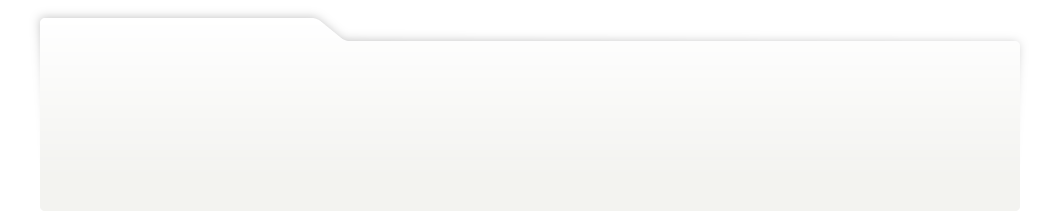
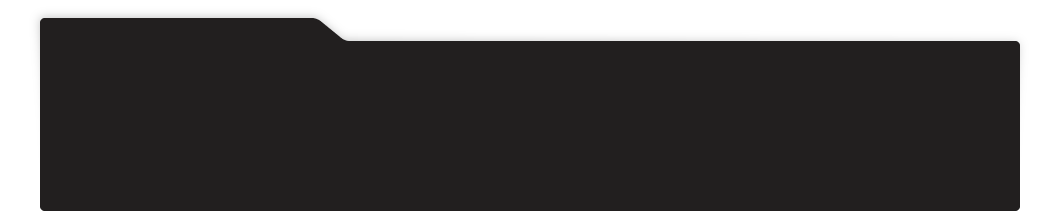
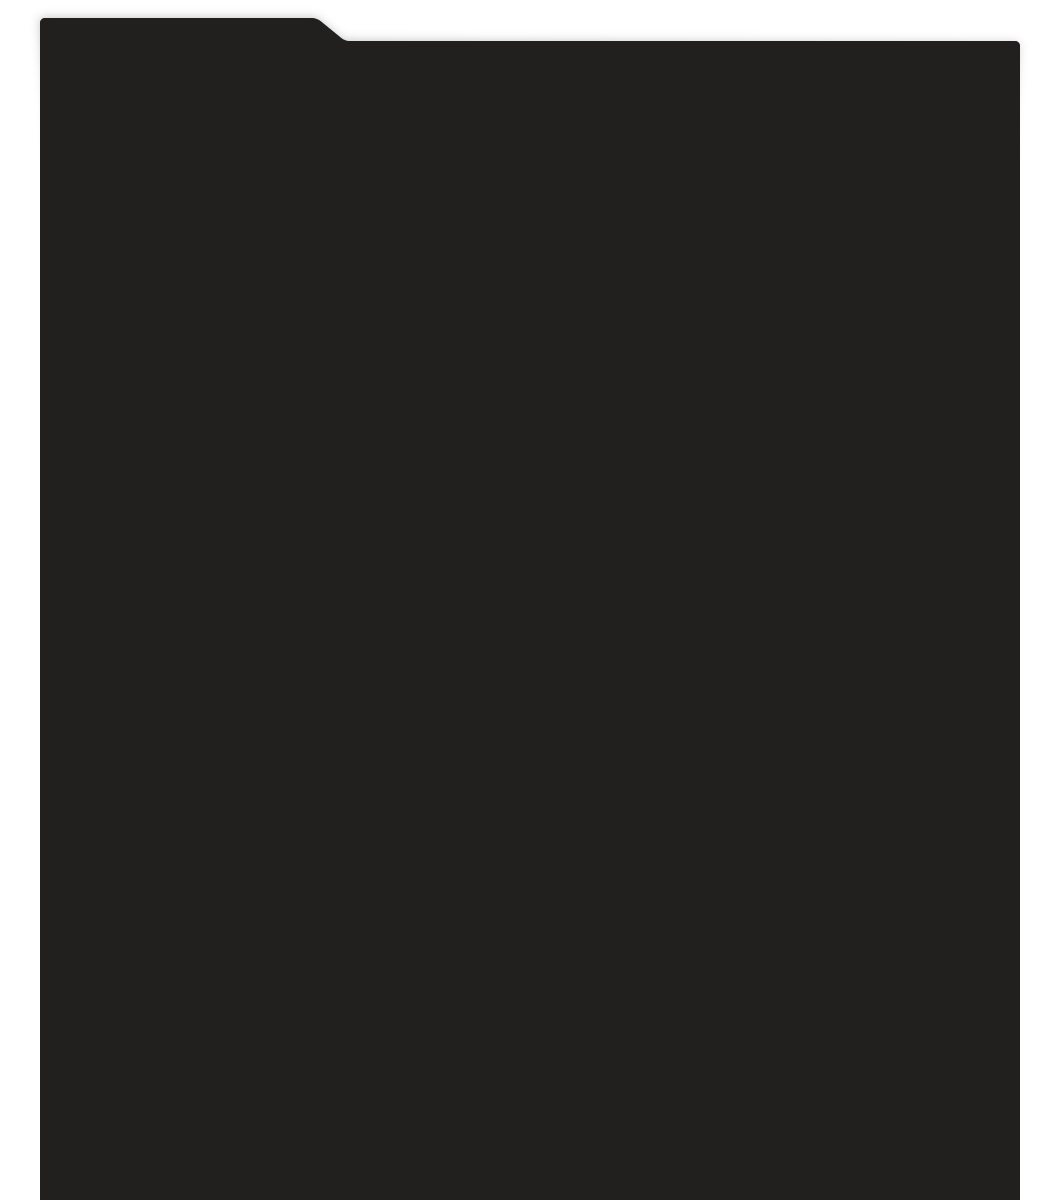
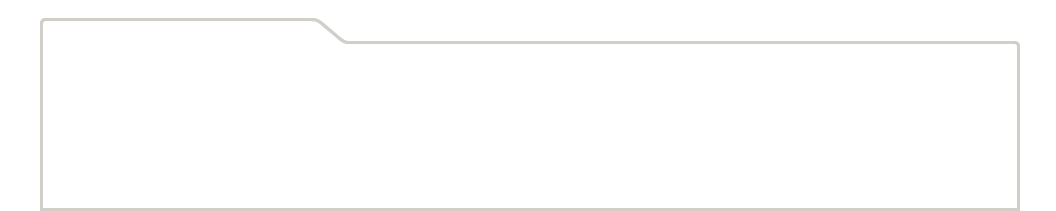
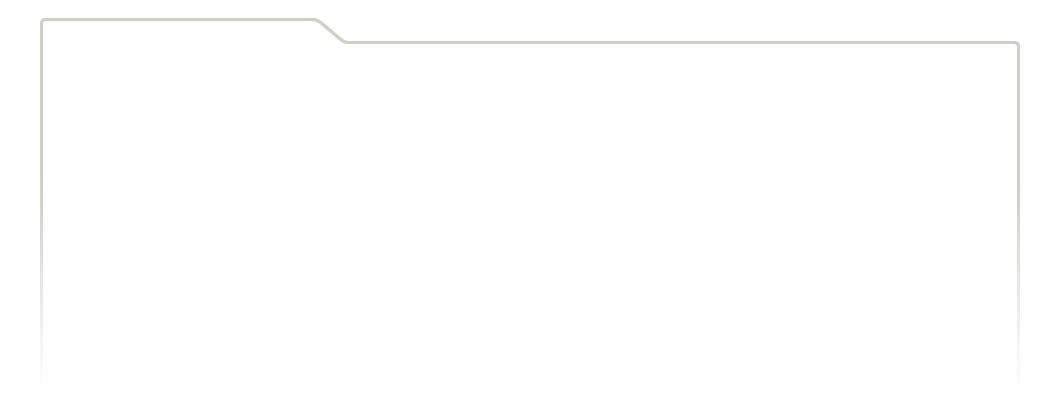
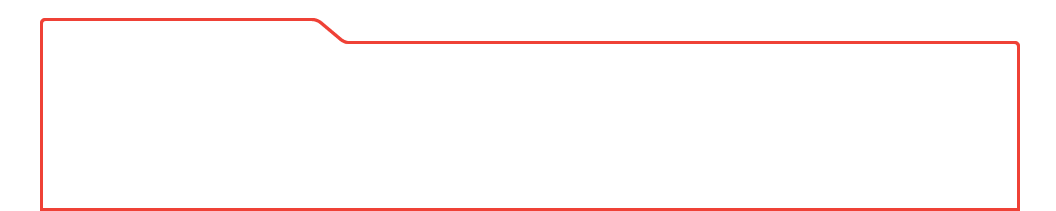
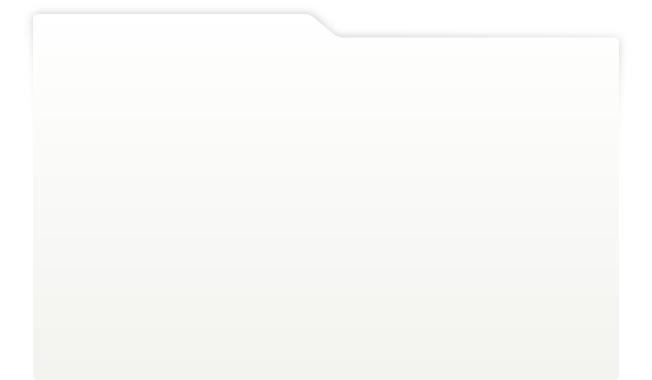
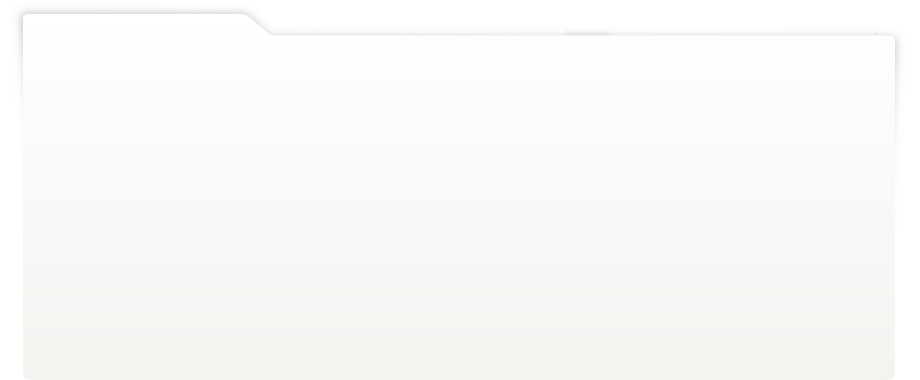
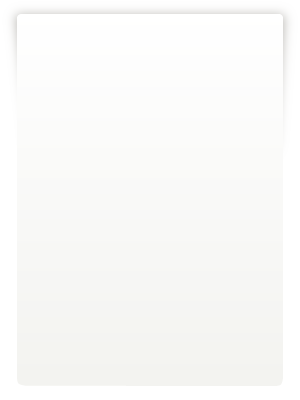
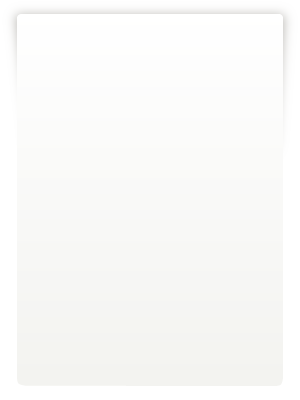
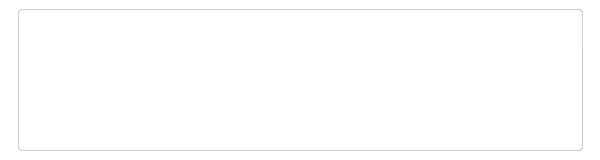
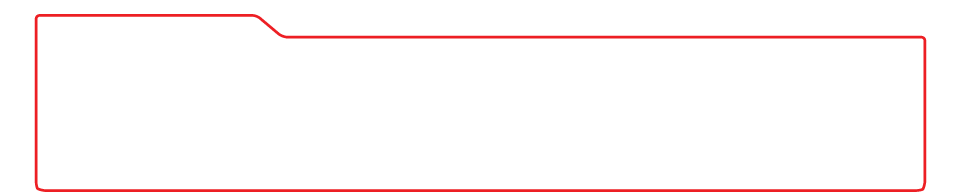
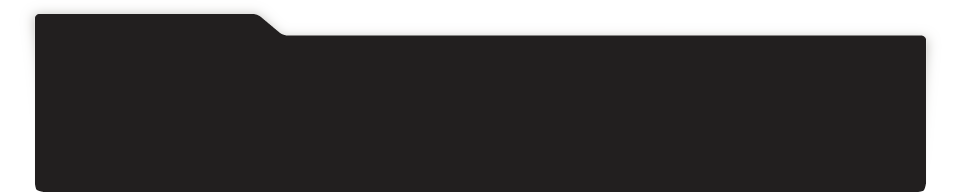
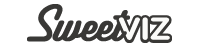
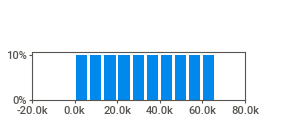
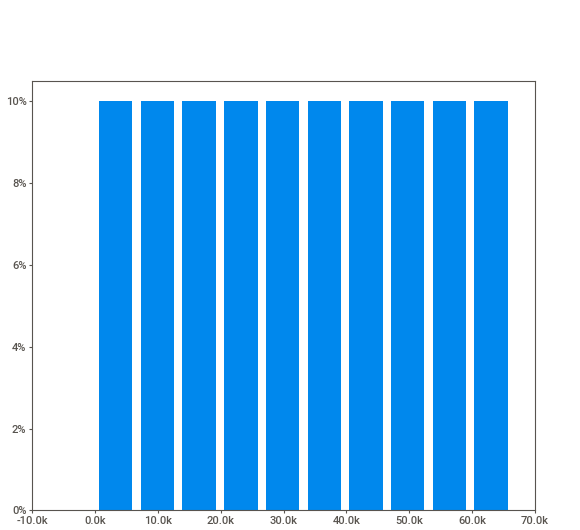
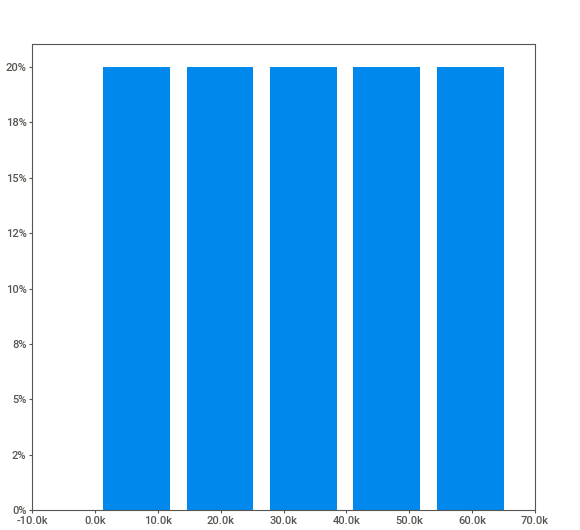
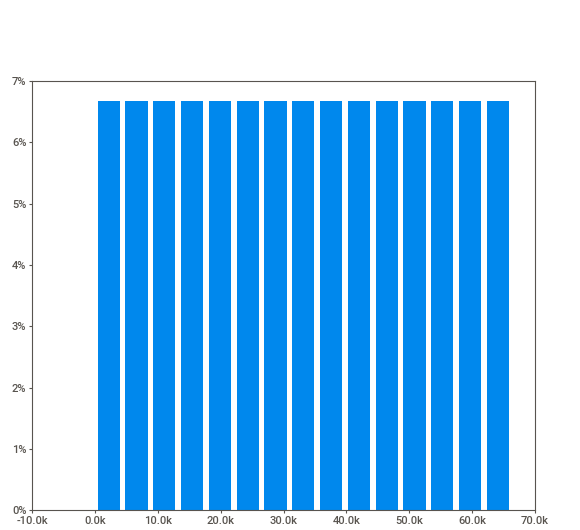
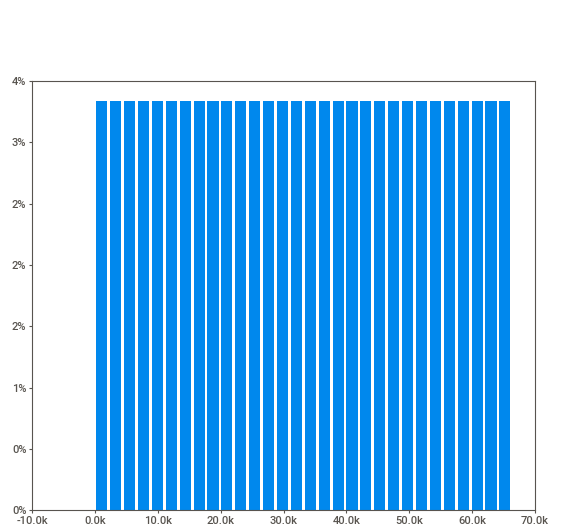
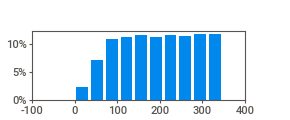
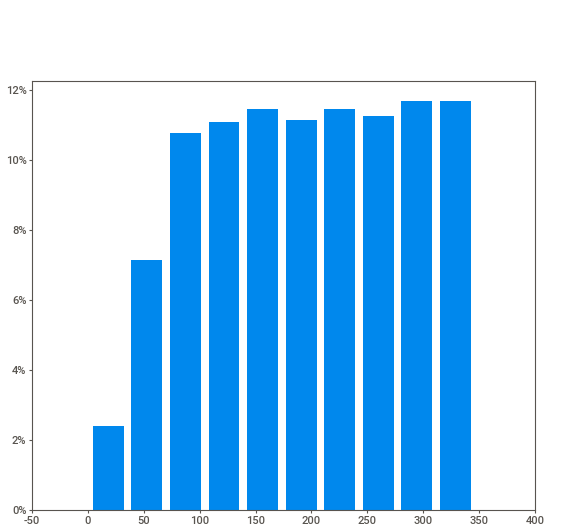
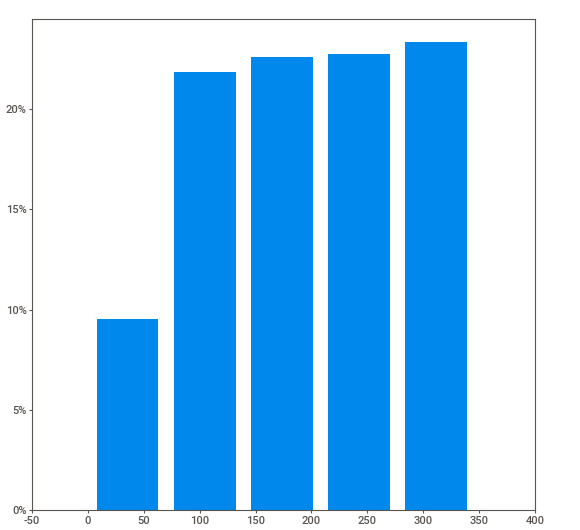
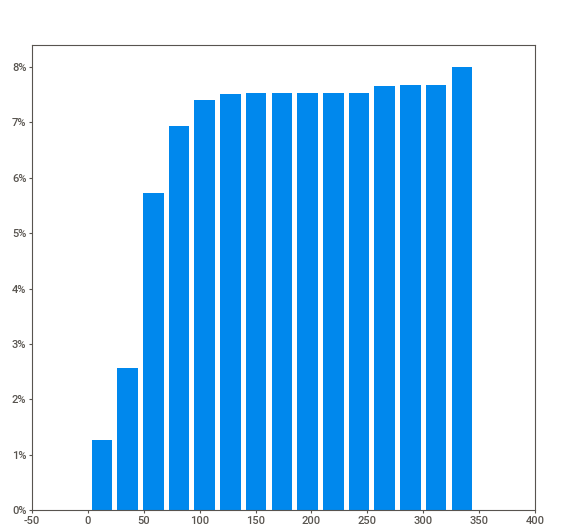
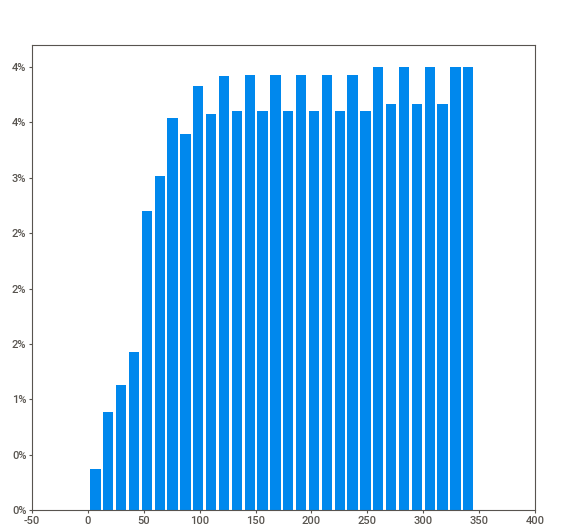
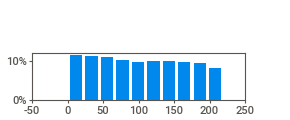
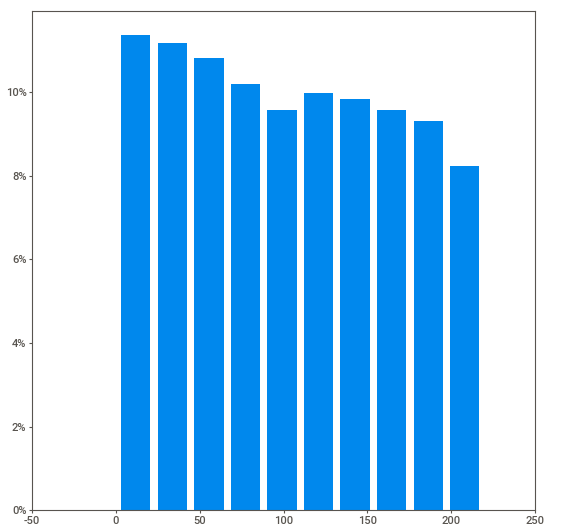
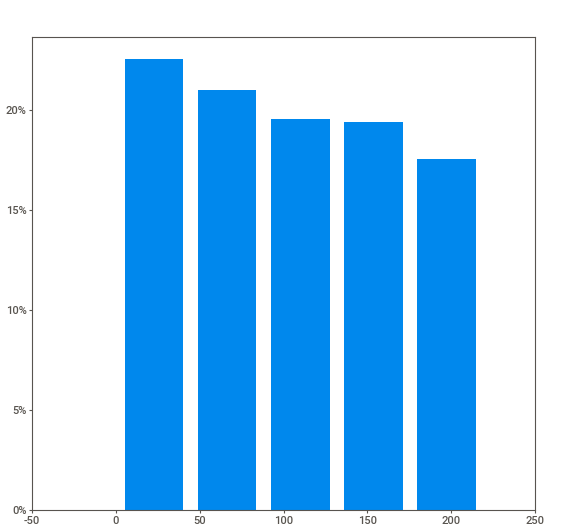
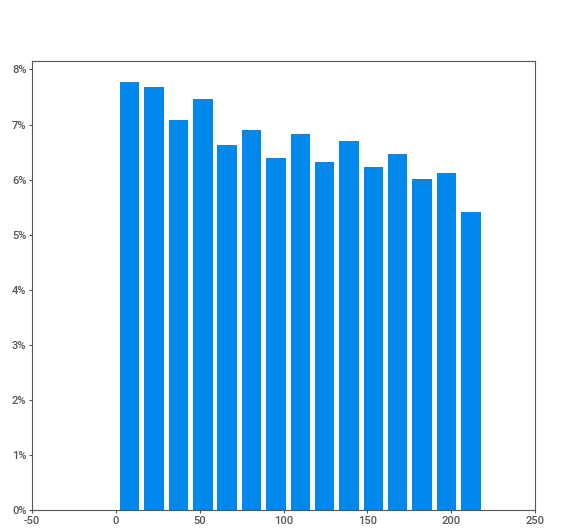
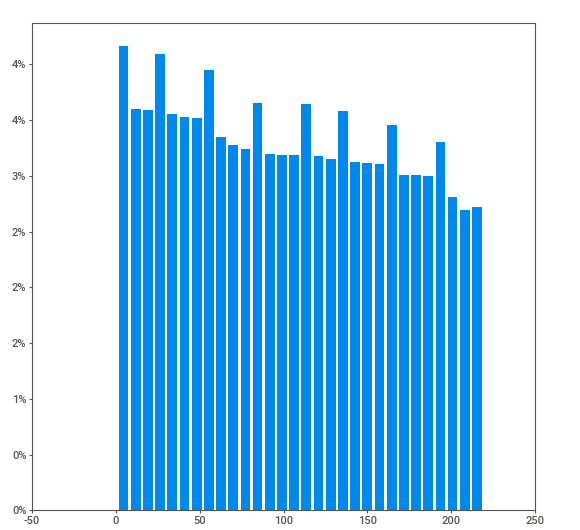
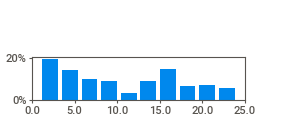
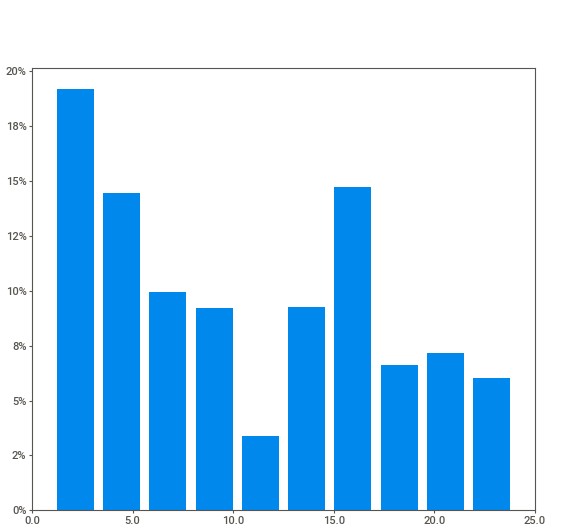
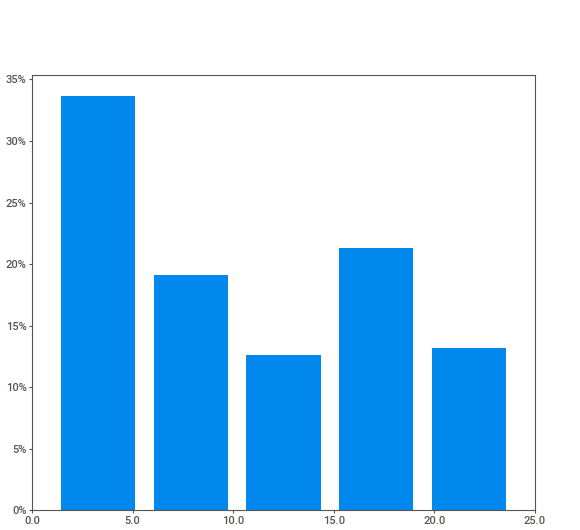
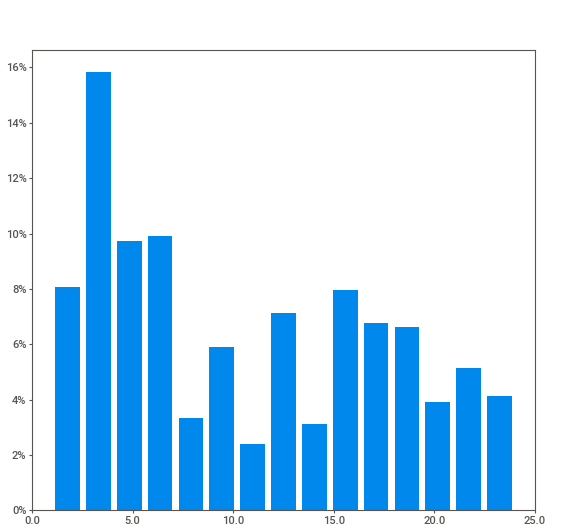
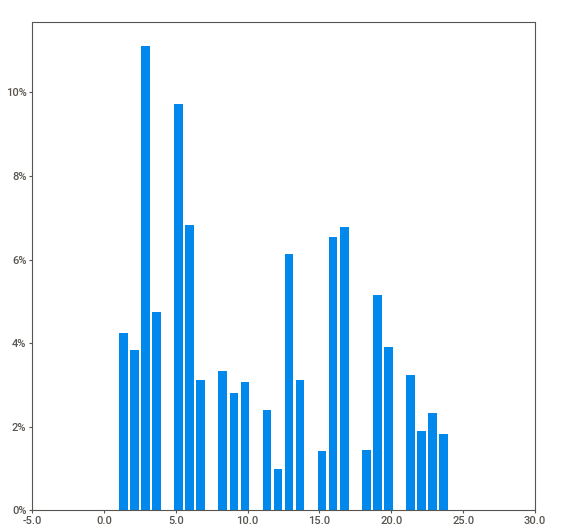
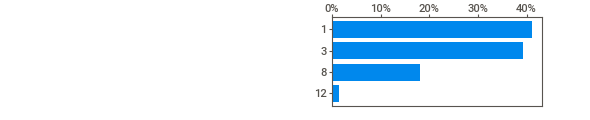
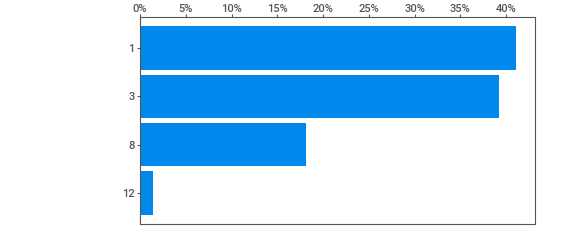
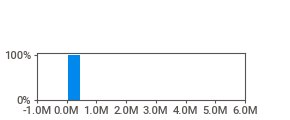
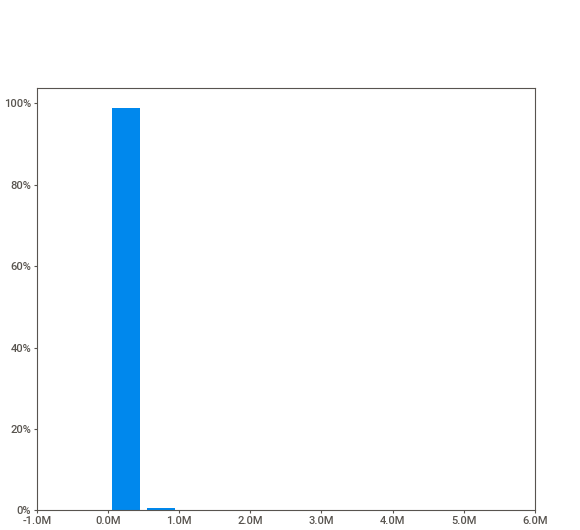
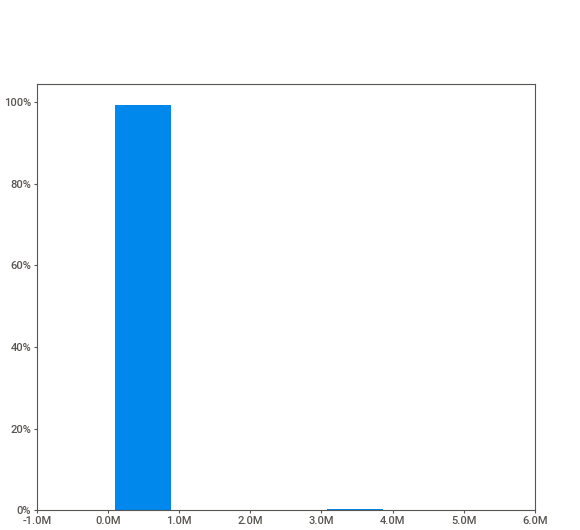
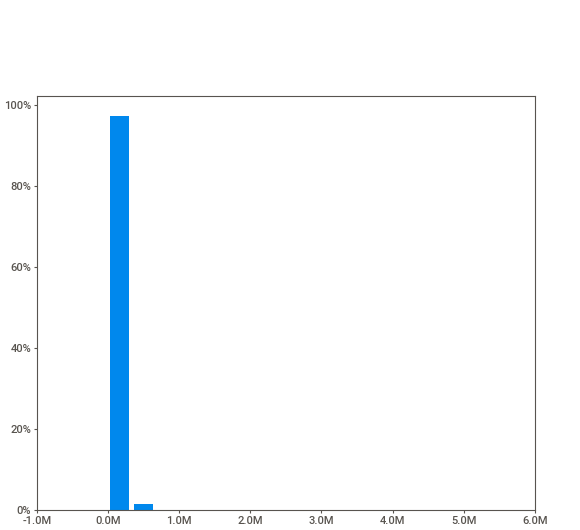
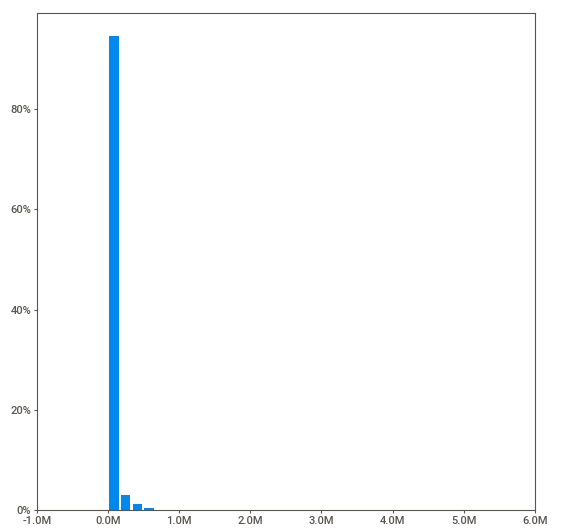
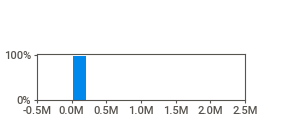
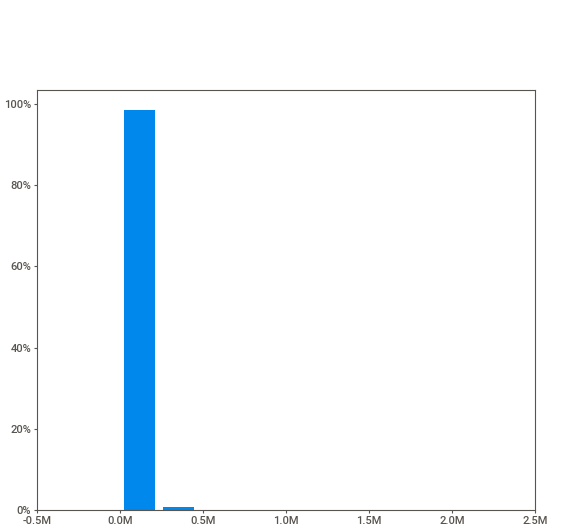
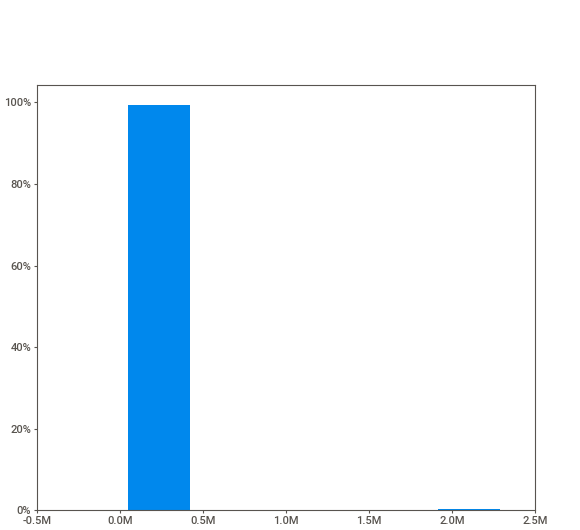
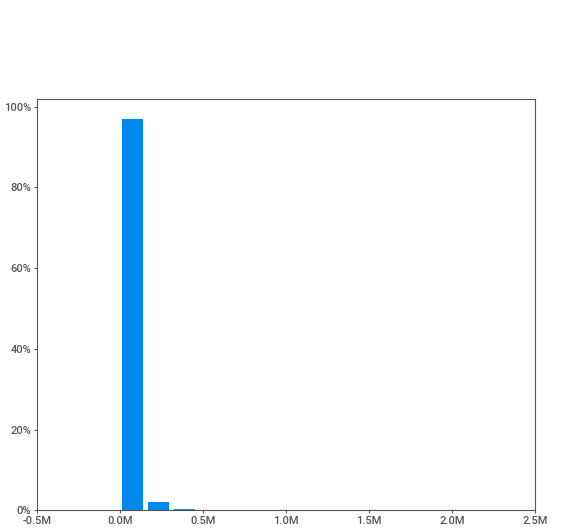
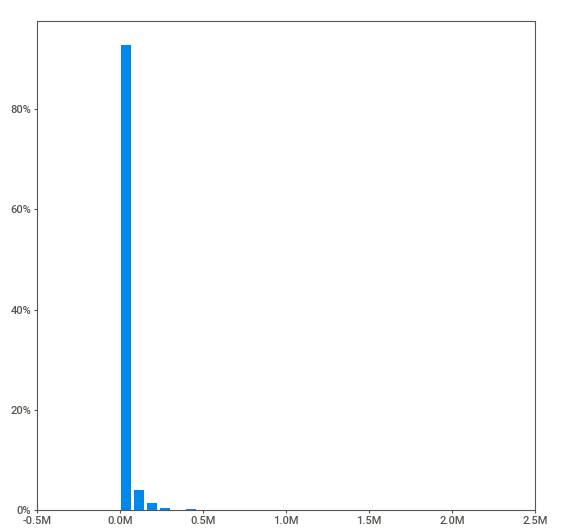
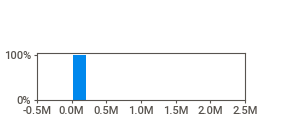
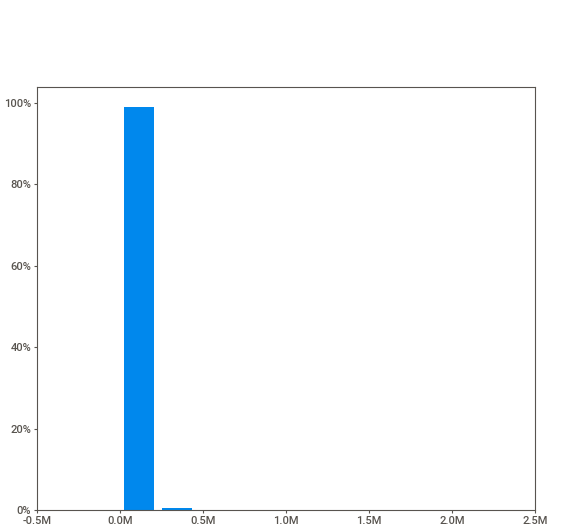
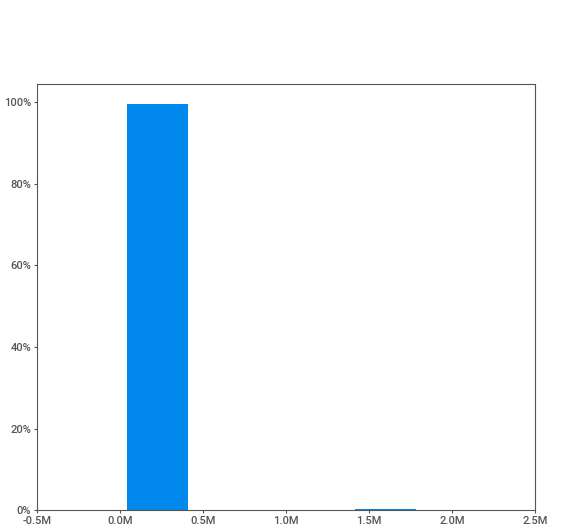
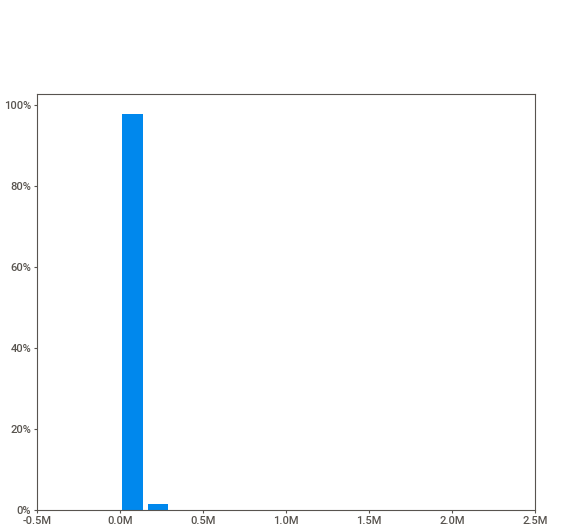
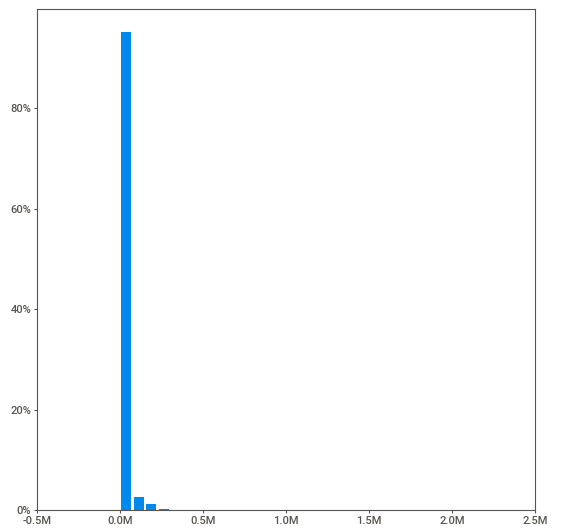
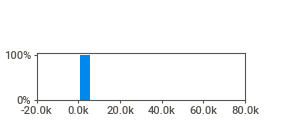
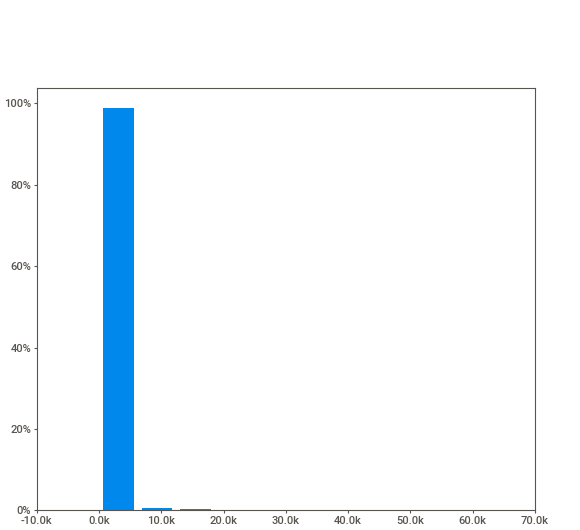
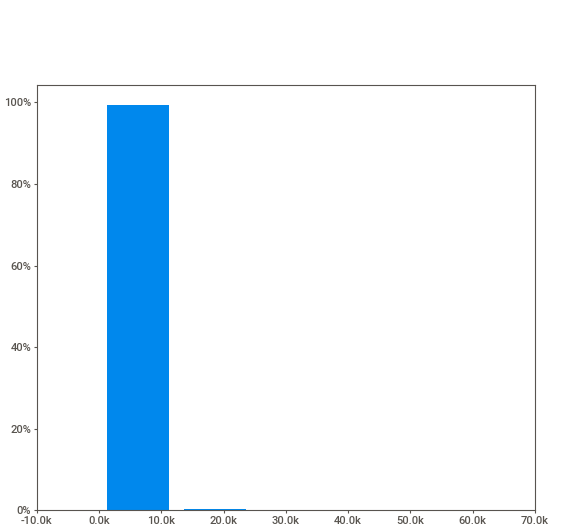
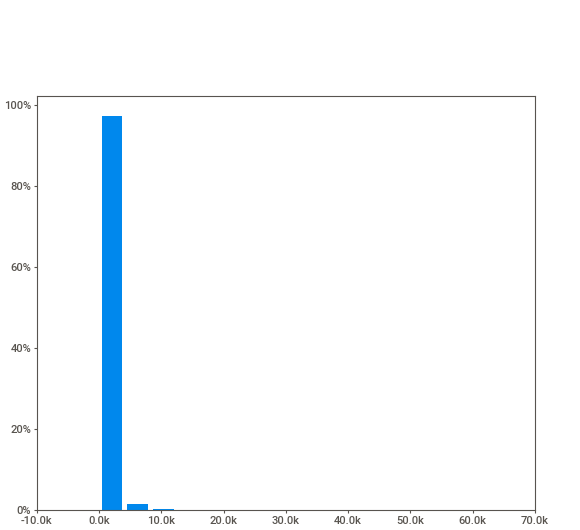
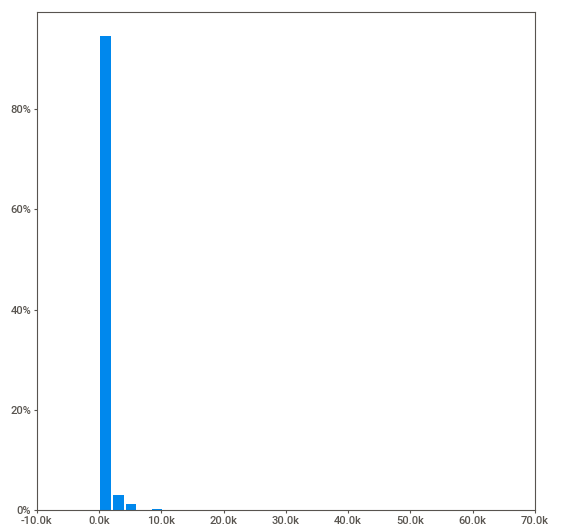
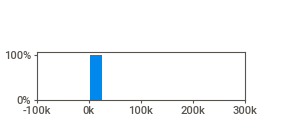
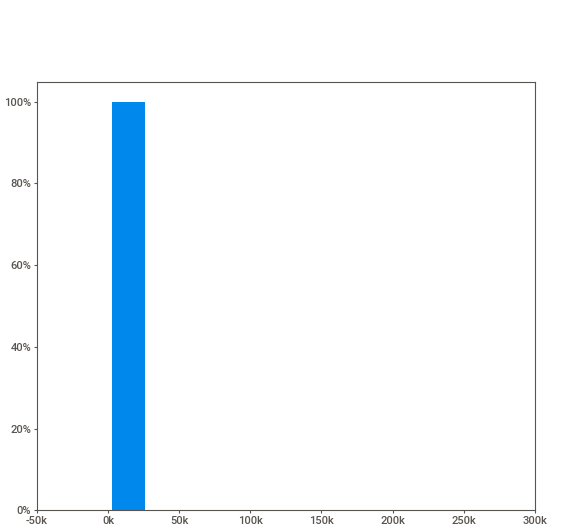
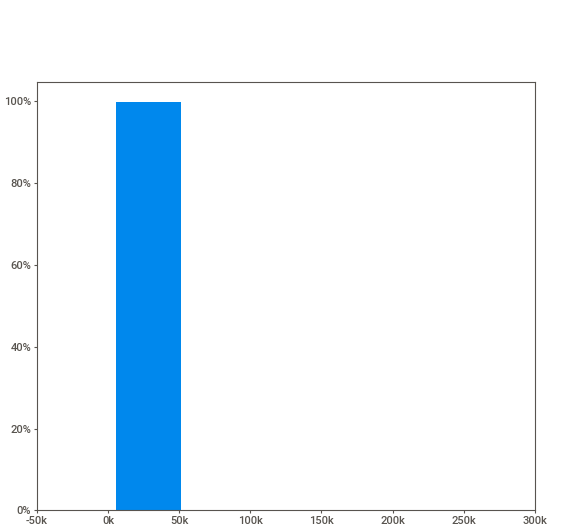
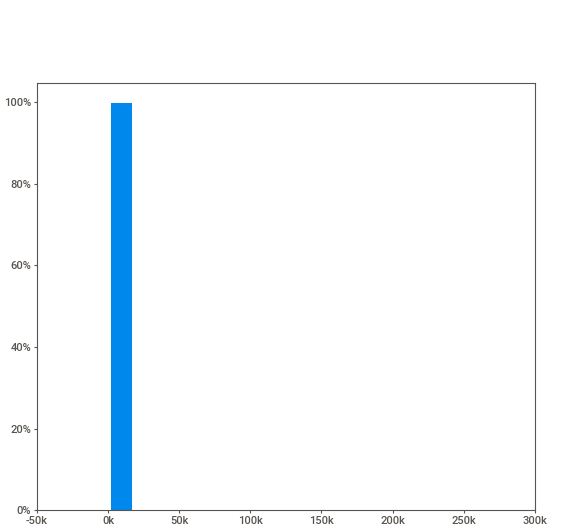
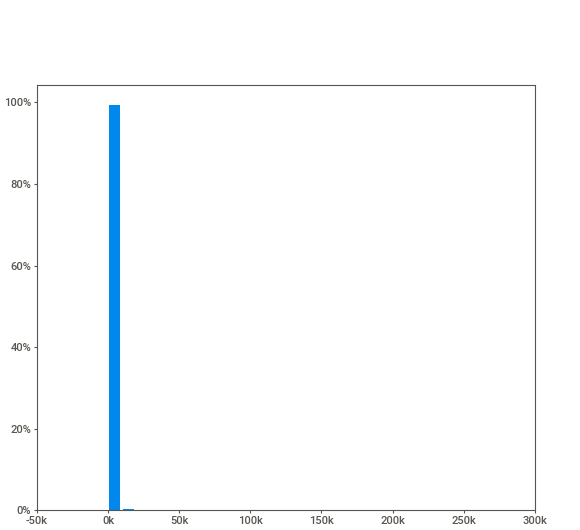
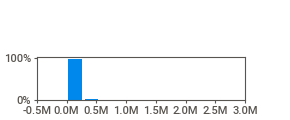
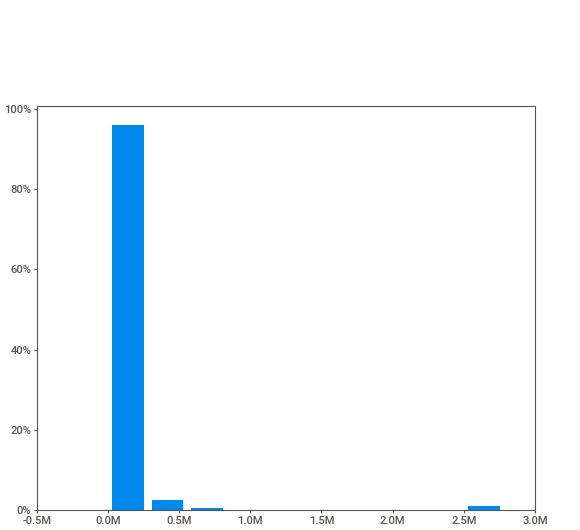
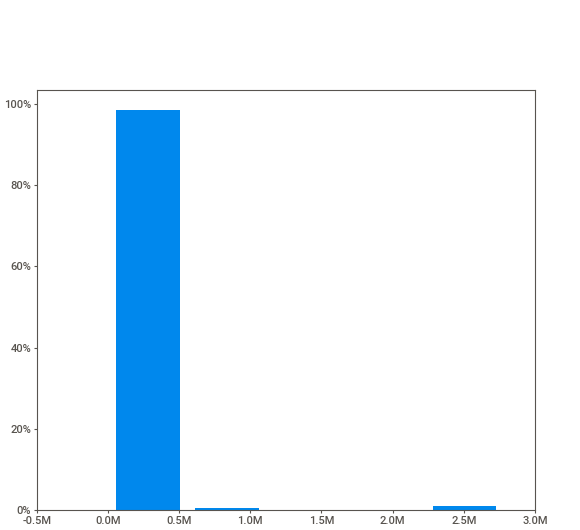
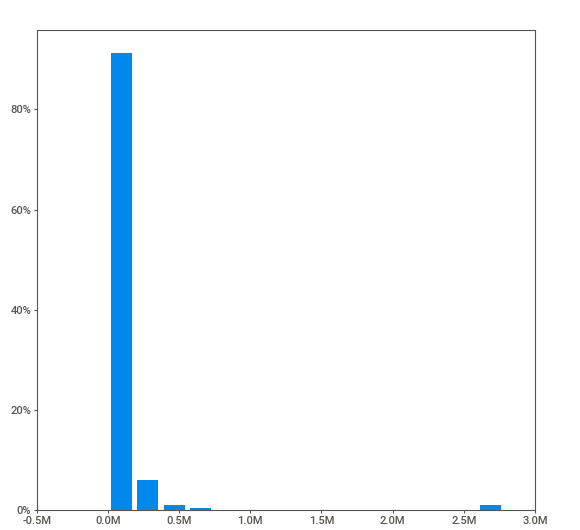
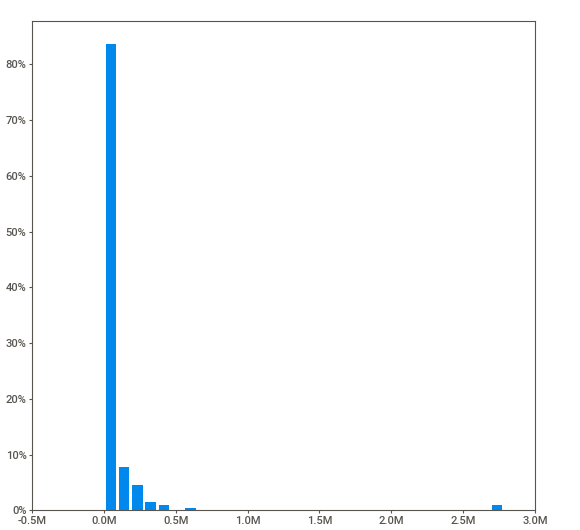
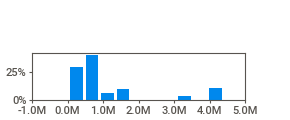
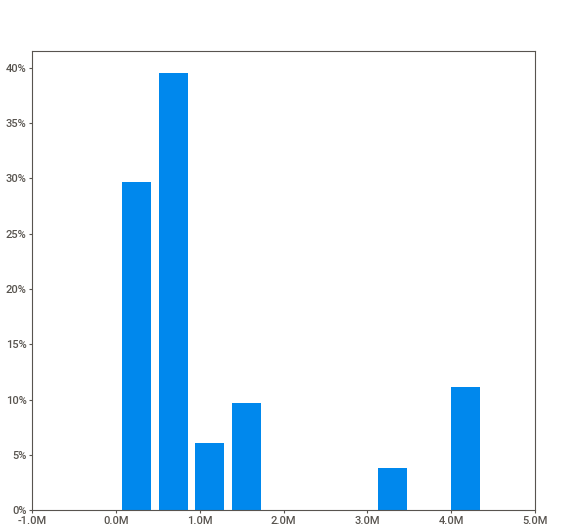
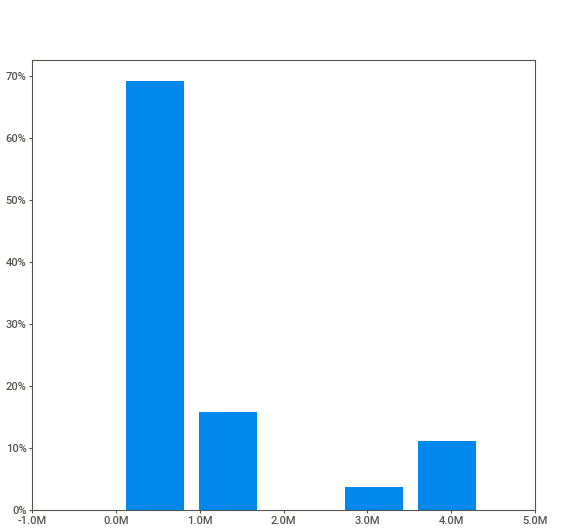
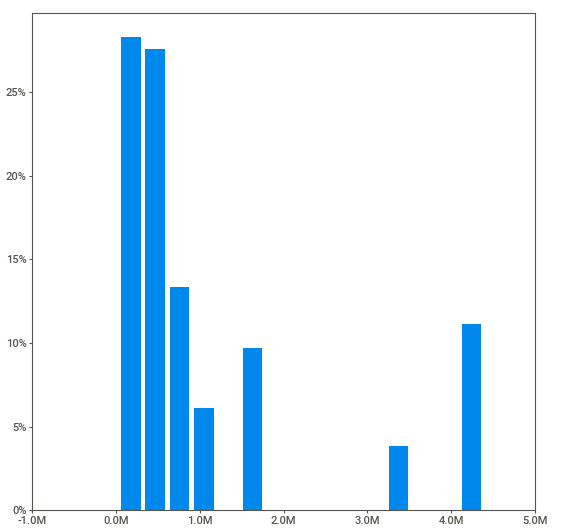
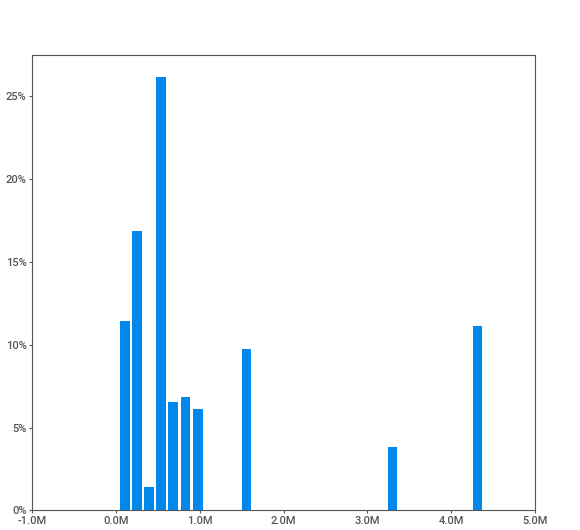
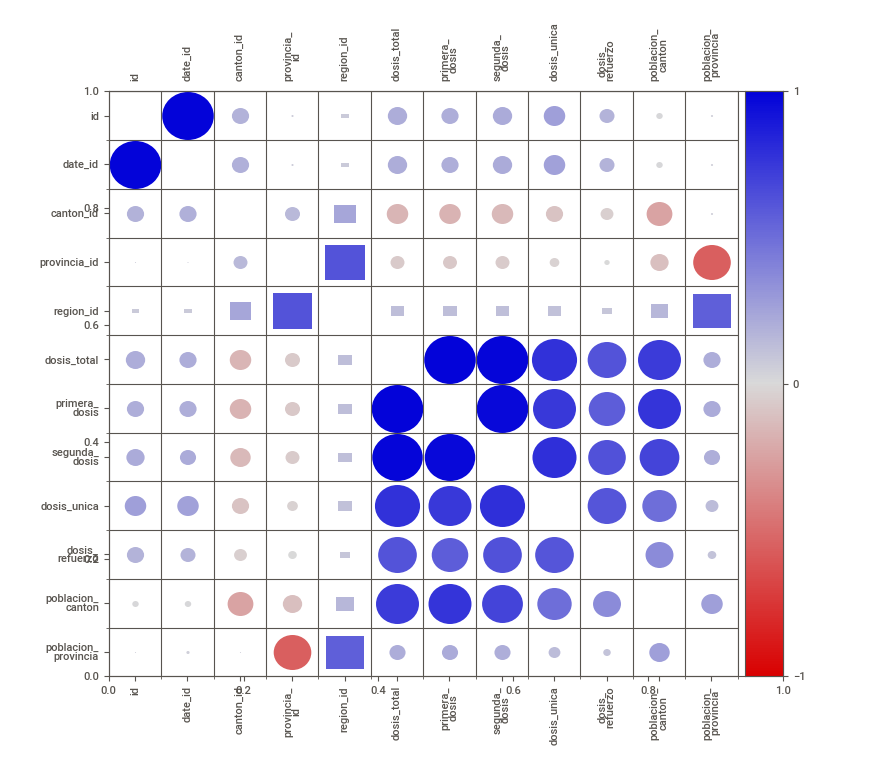
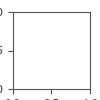

In [6]:
#Reporte 1: fact_vacunacion
# force_num asegura que las columnas de dosis se traten como numéricas (por si quedaron como object tras la carga desde CSV)
fc_fact = FeatureConfig(
    force_num=["dosis_total", "primera_dosis", "segunda_dosis",
               "dosis_unica", "dosis_refuerzo",
               "poblacion_canton", "poblacion_provincia"]
)
rep_fact = sv.analyze(df_fact, feat_cfg=fc_fact)
rep_fact.show_html(ruta + "sweetviz_fact.html", open_browser=False)
print("Reporte tf_fact guardado en Drive")
rep_fact.show_notebook()

                                             |          | [  0%]   00:00 -> (? left)

Report /content/drive/Shared drives/ETL_second_delivery/sweetviz_covid.html was generated.
Reporte tf_covid guardado en Drive



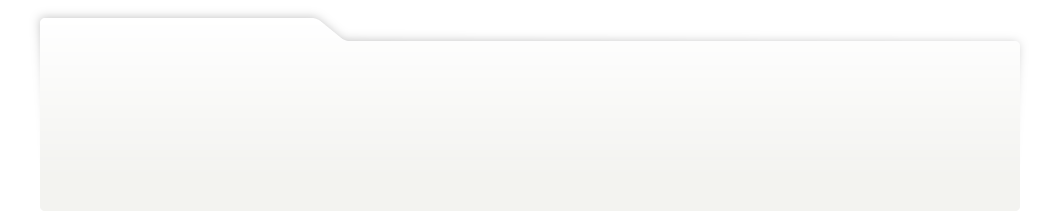
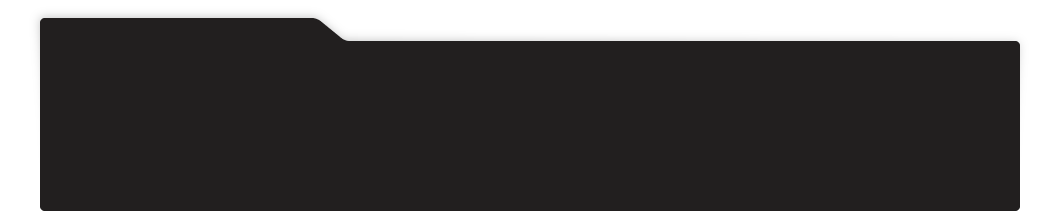
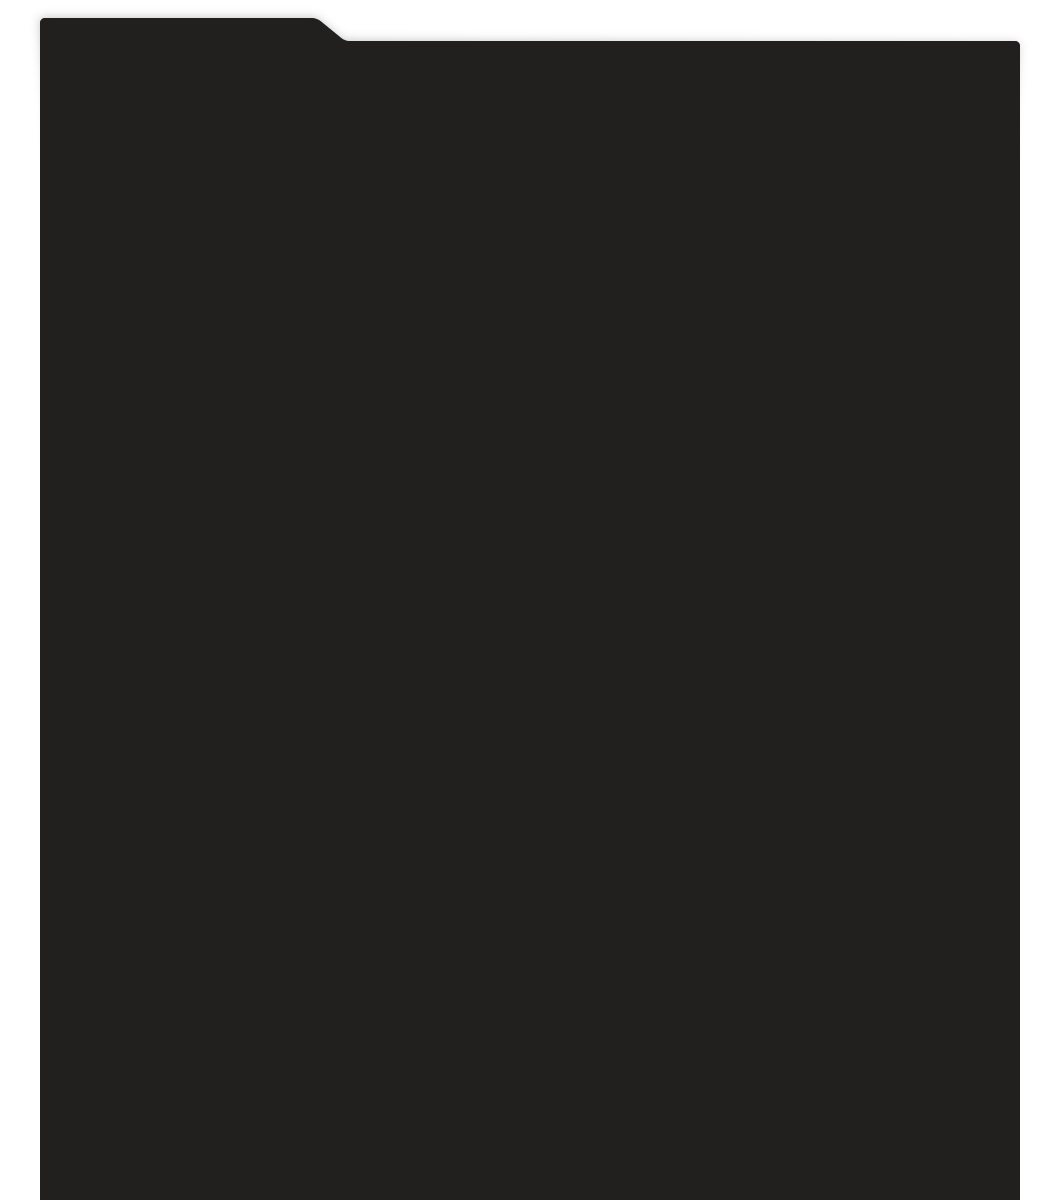
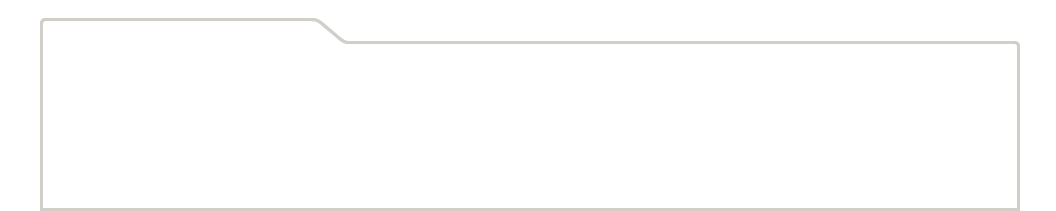
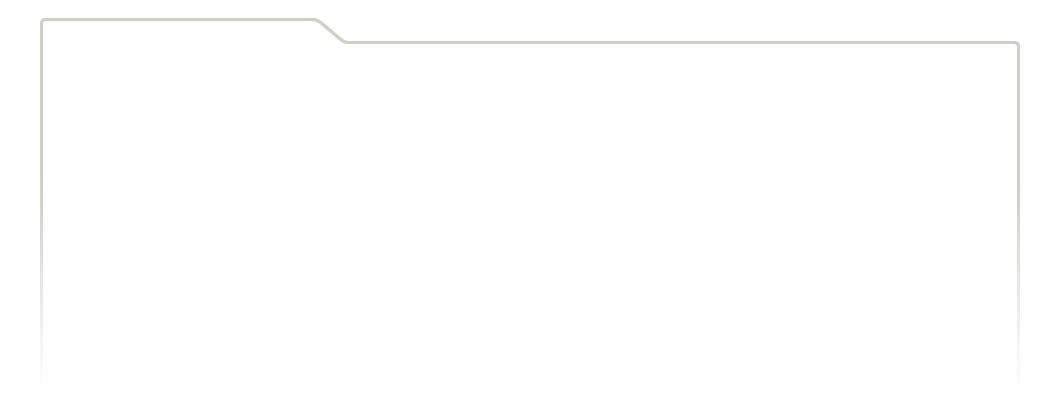
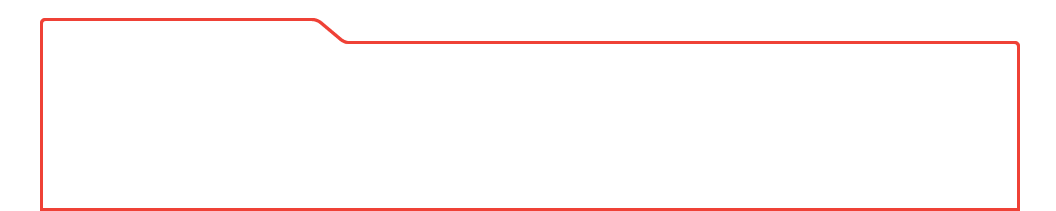
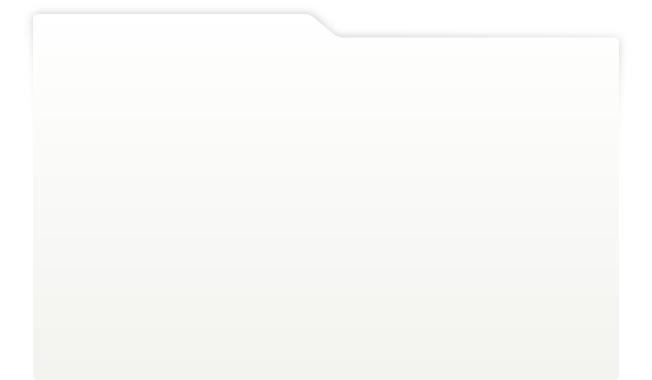
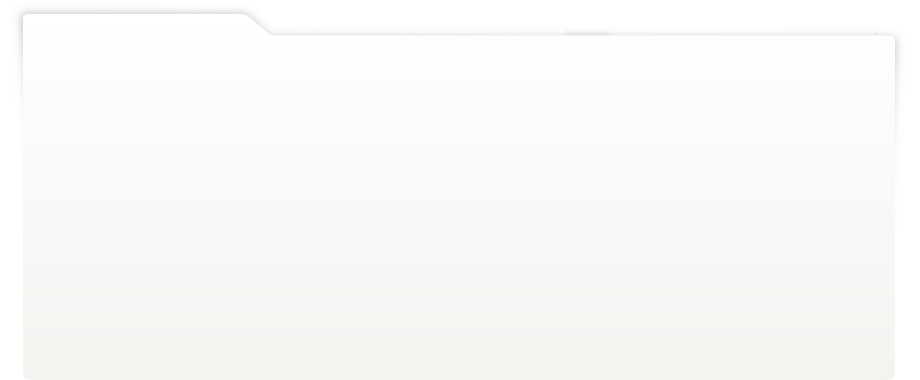
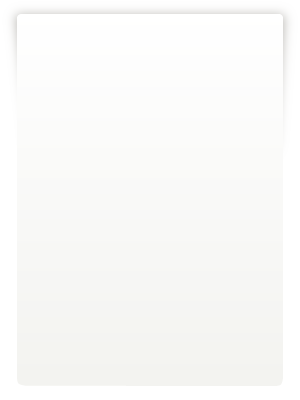
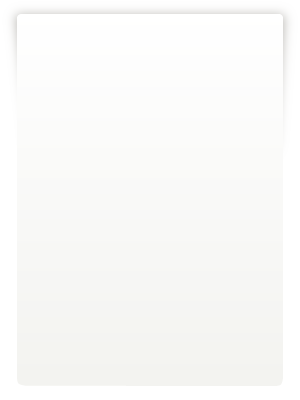
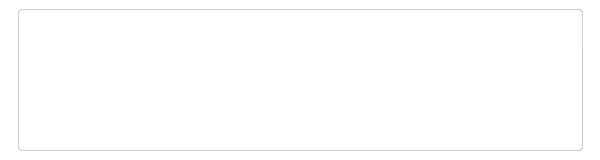
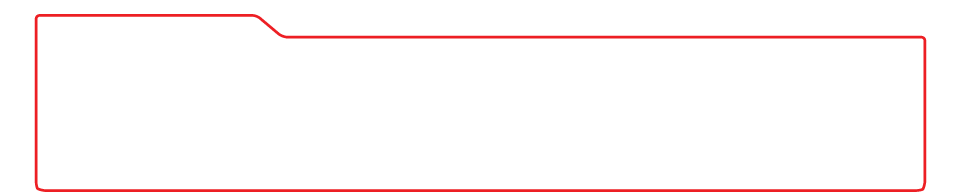
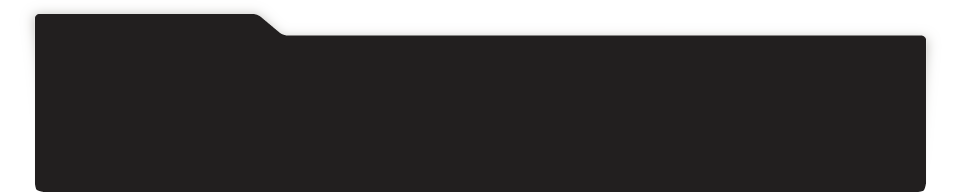
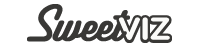
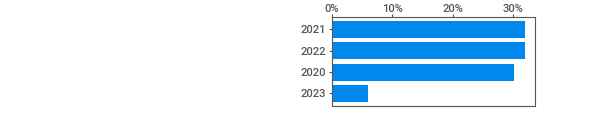
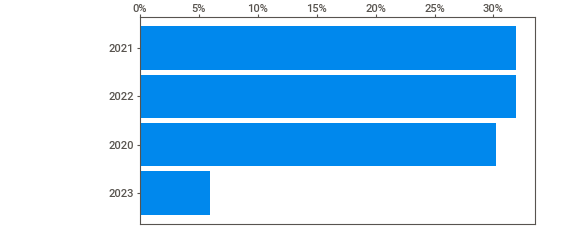
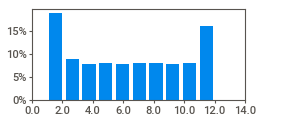
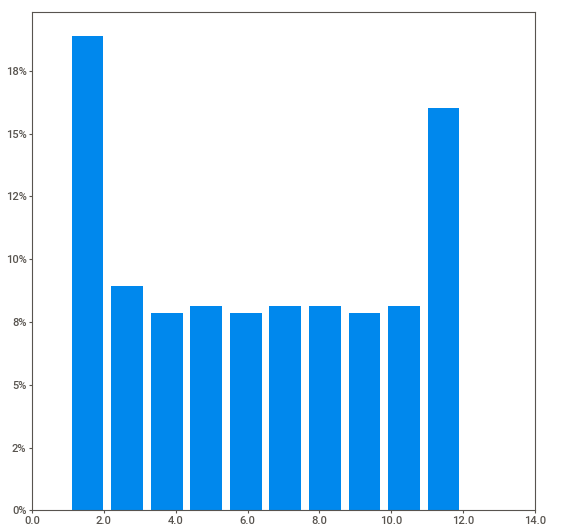
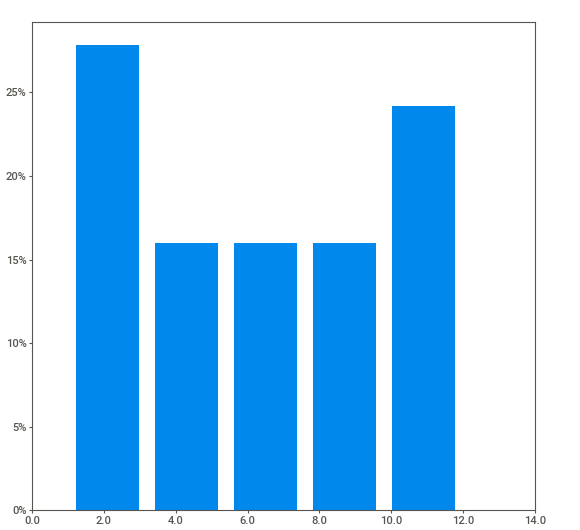
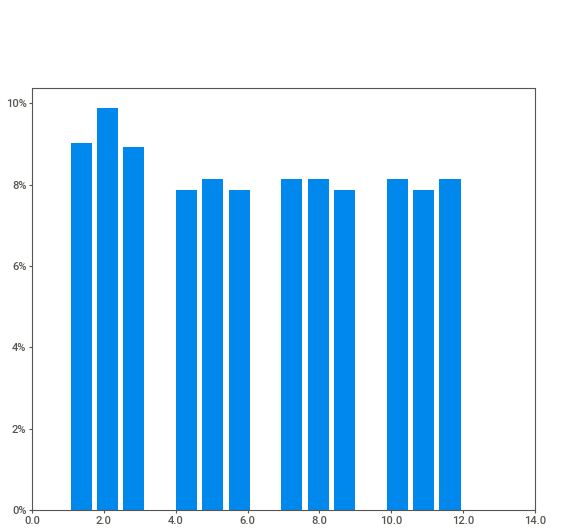
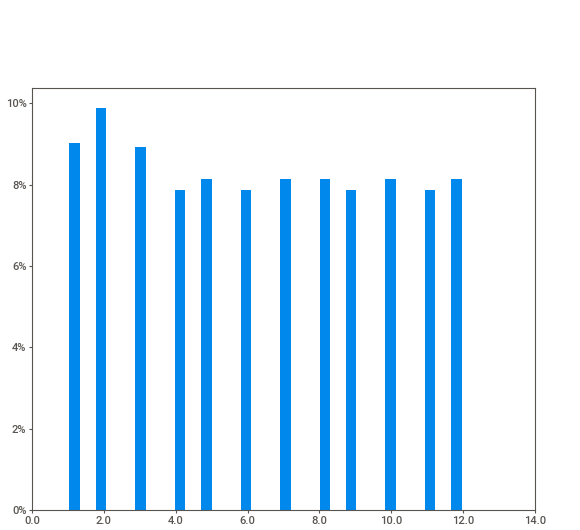
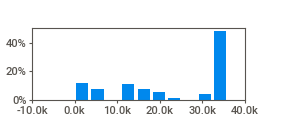
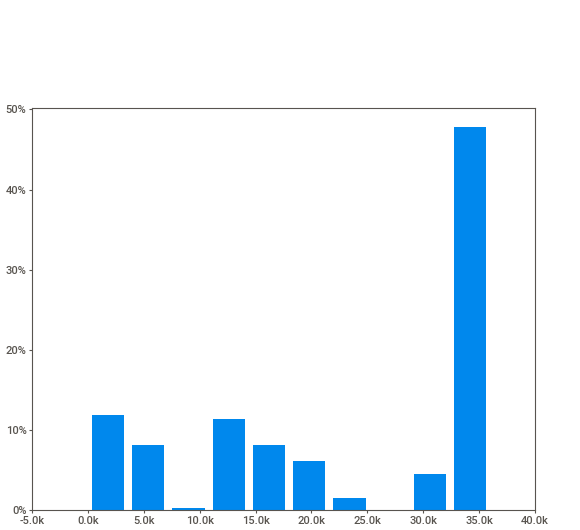
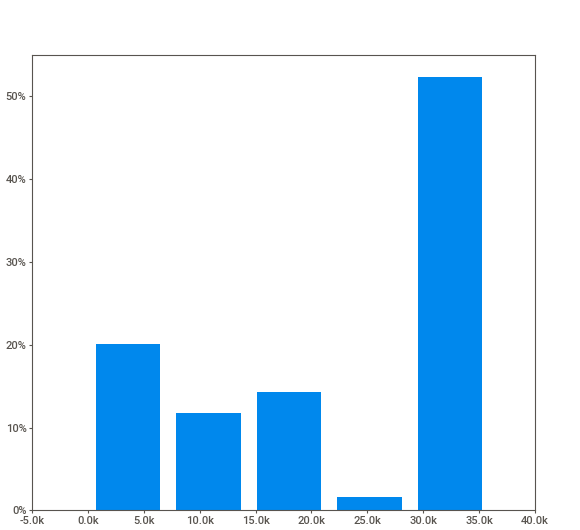
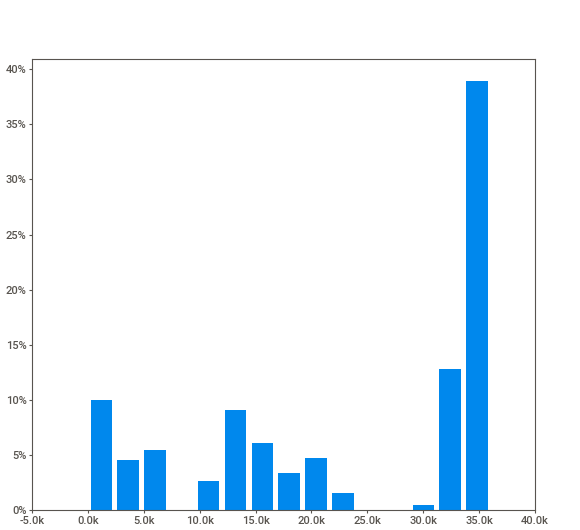
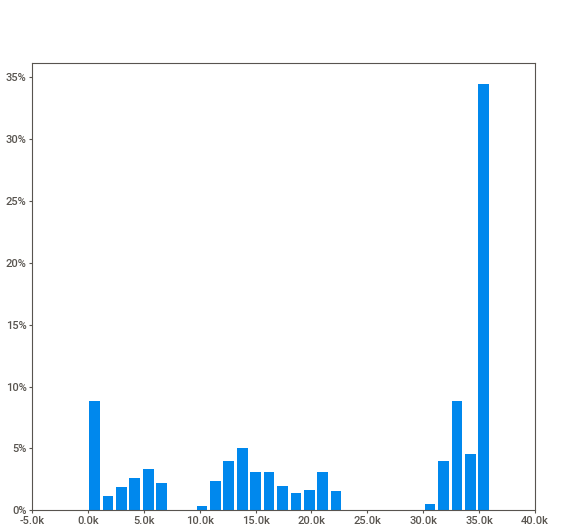
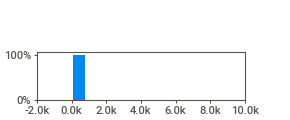
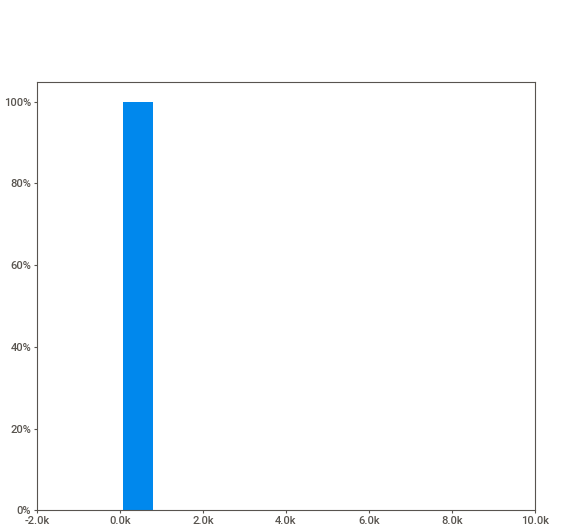
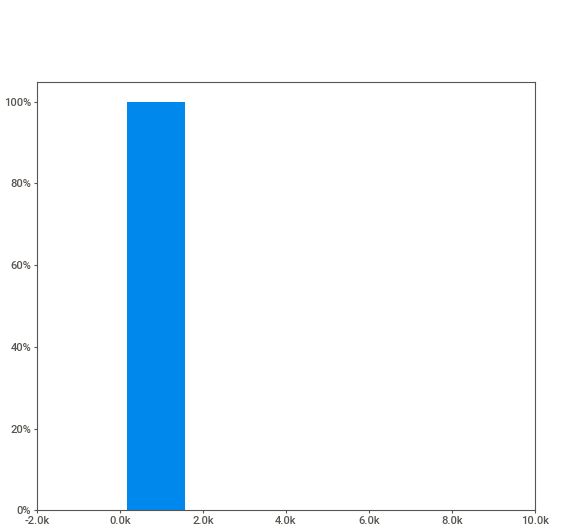
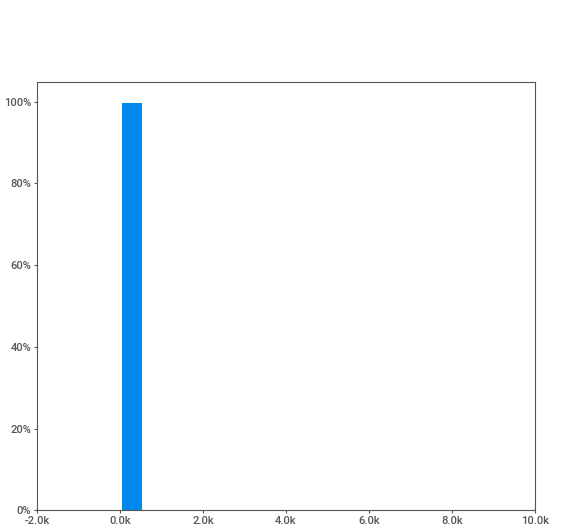
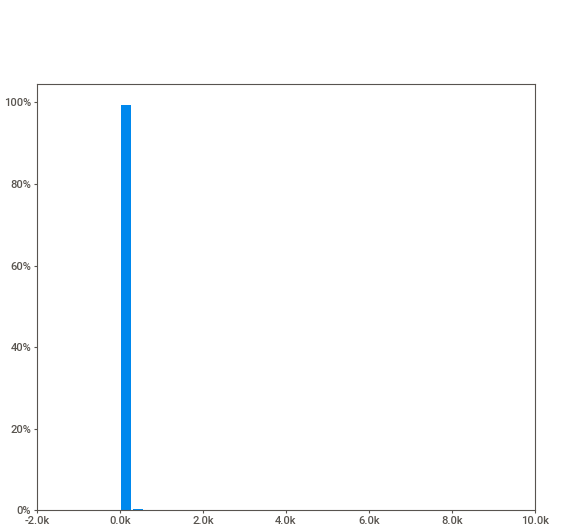
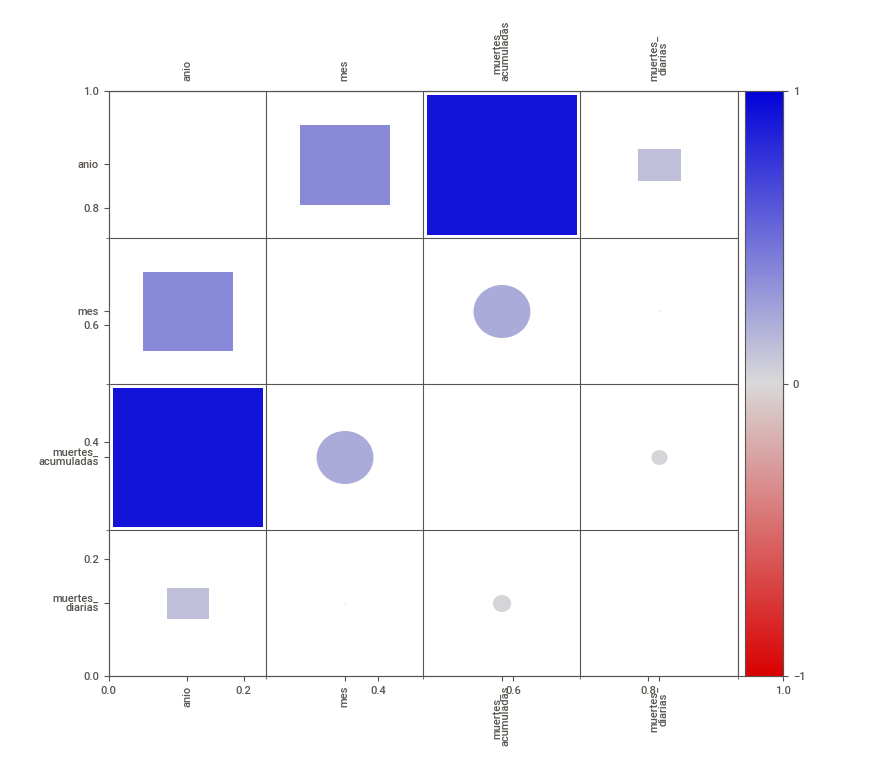
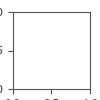

In [7]:
#eeporte 2: covid_deaths_ecuador
rep_covid = sv.analyze(df_covid)
rep_covid.show_html(ruta + "sweetviz_covid.html", open_browser=False)
print("Reporte tf_covid guardado en Drive")
rep_covid.show_notebook()

                                             |          | [  0%]   00:00 -> (? left)

Report /content/drive/Shared drives/ETL_second_delivery/sweetviz_uhc.html was generated.
Reporte tf_uhc guardado en Drive



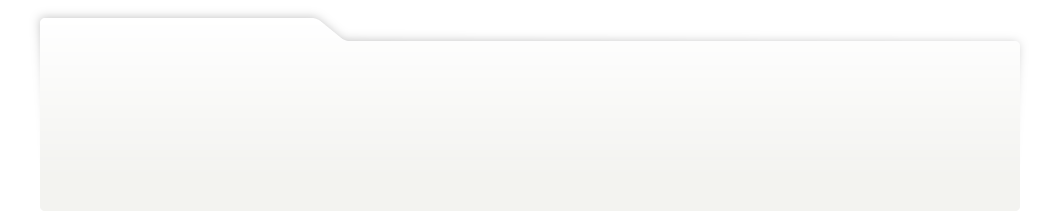
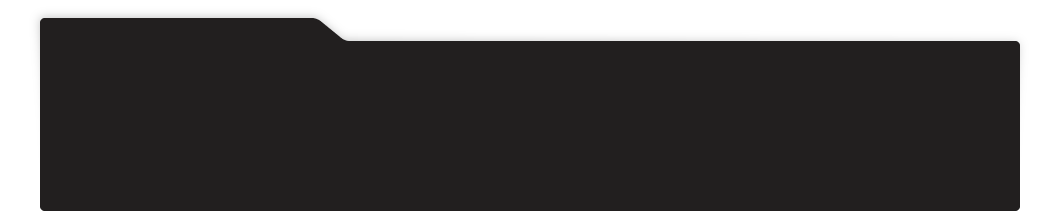
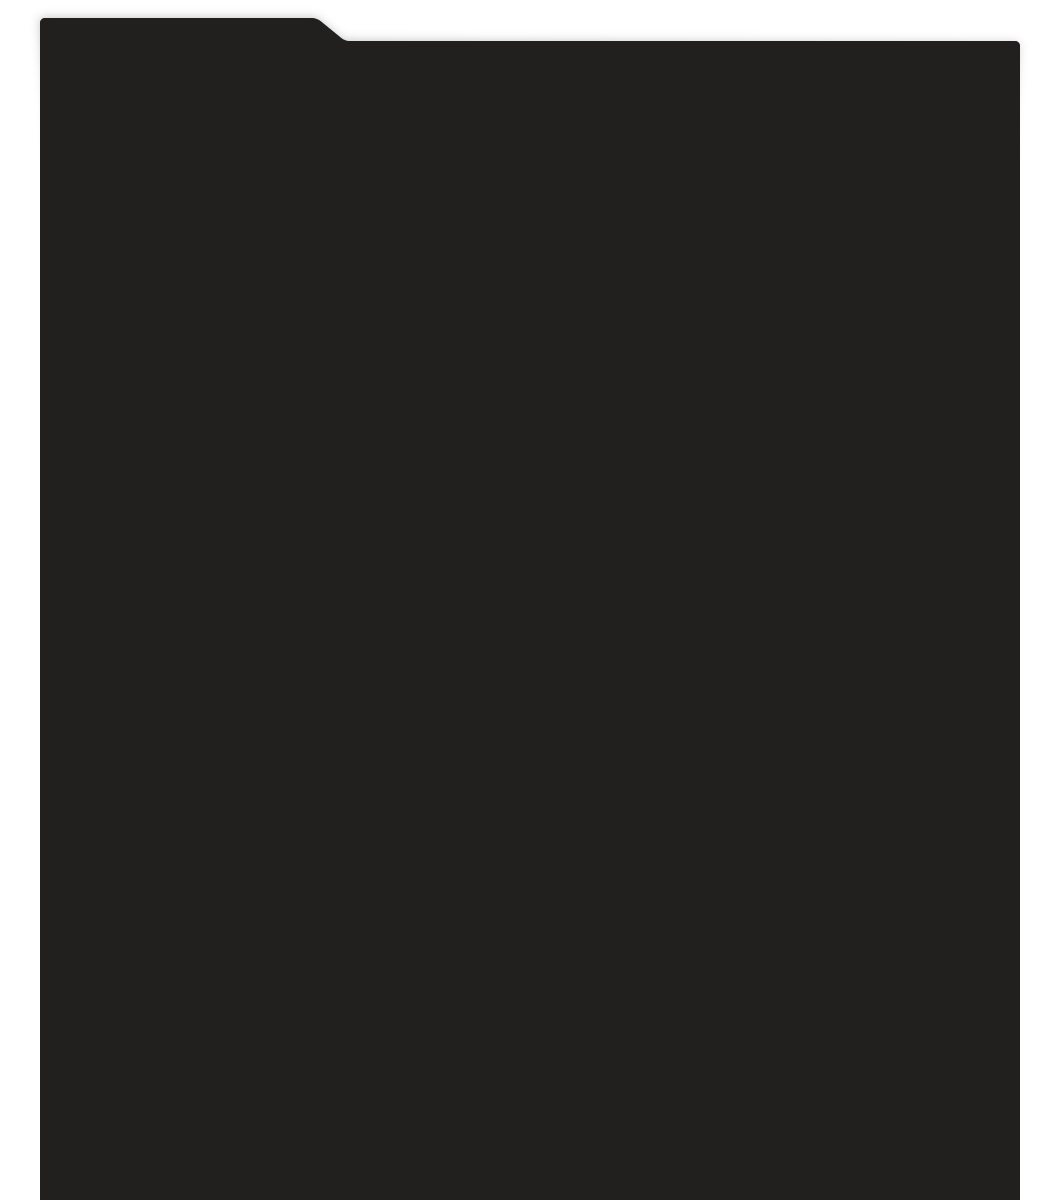
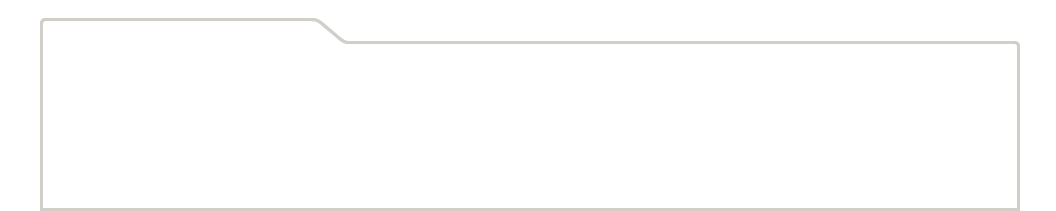
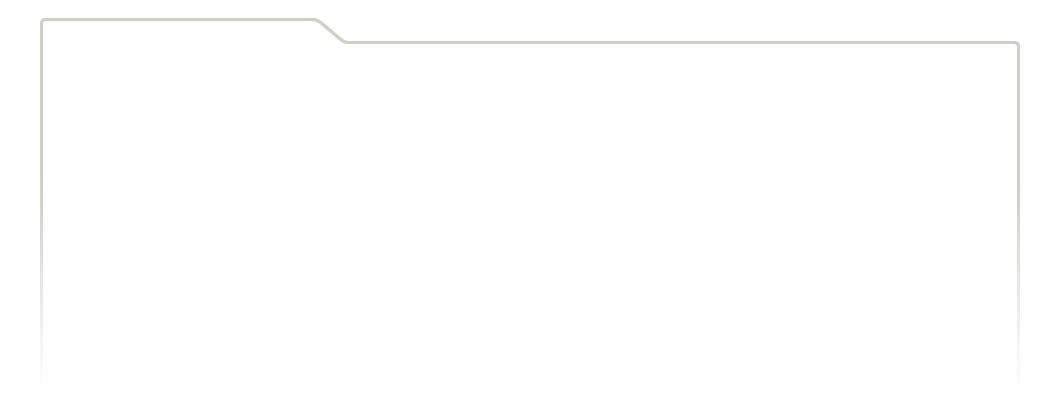
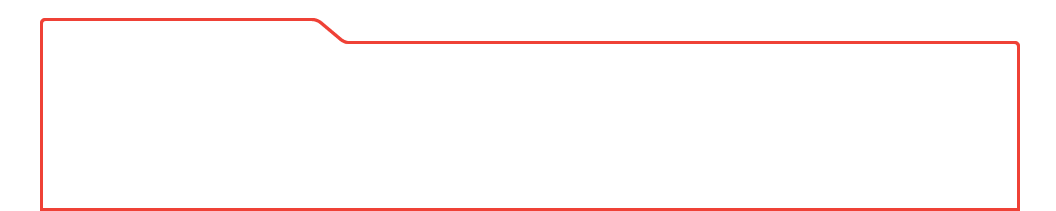
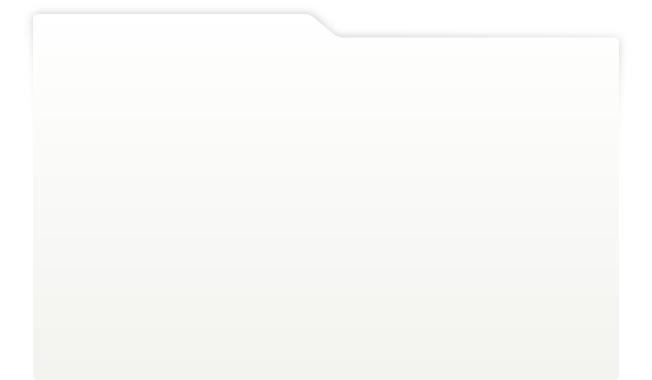
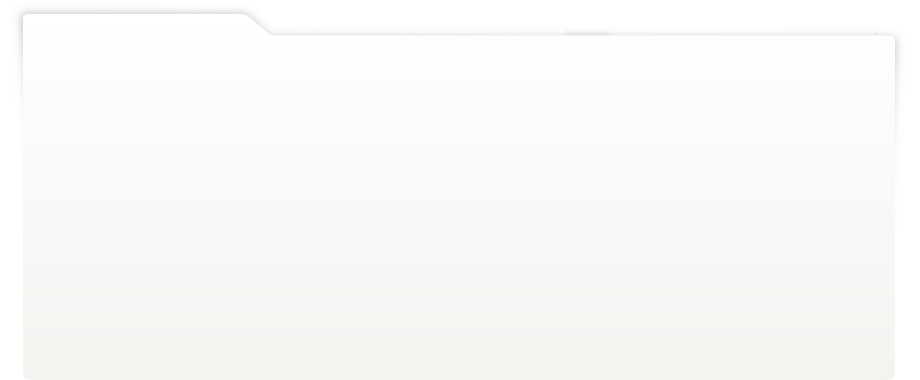
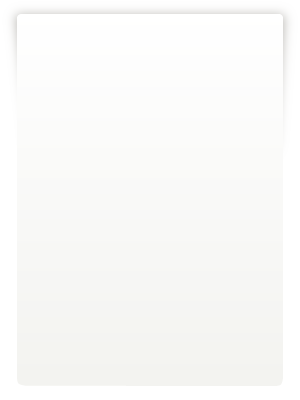
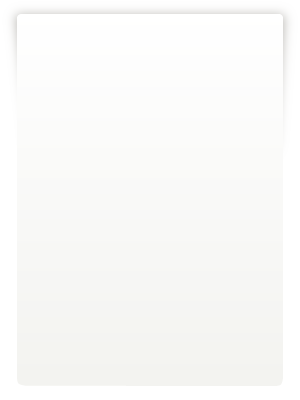
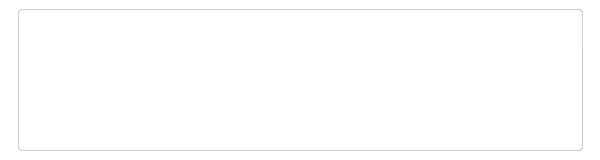
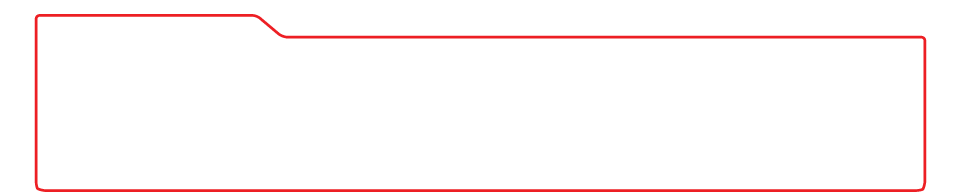
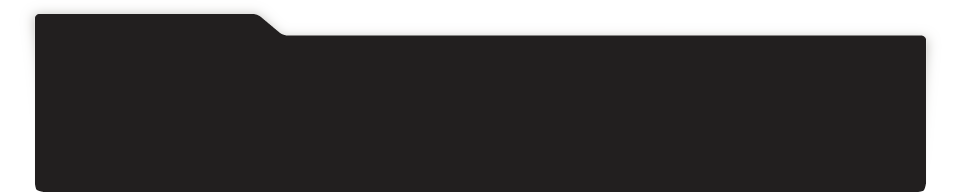
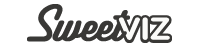
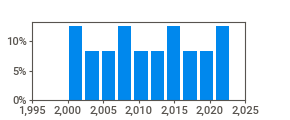
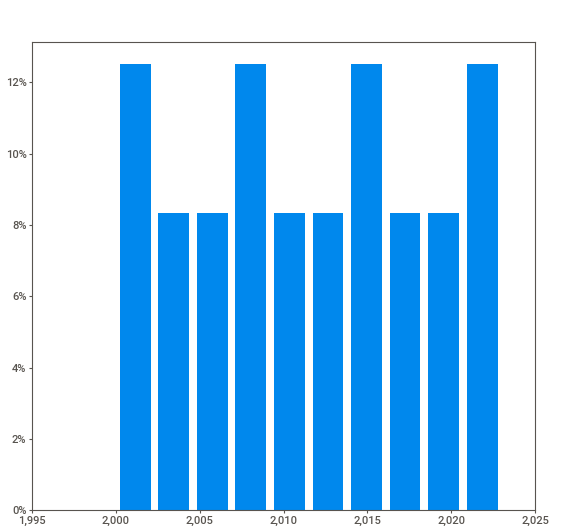
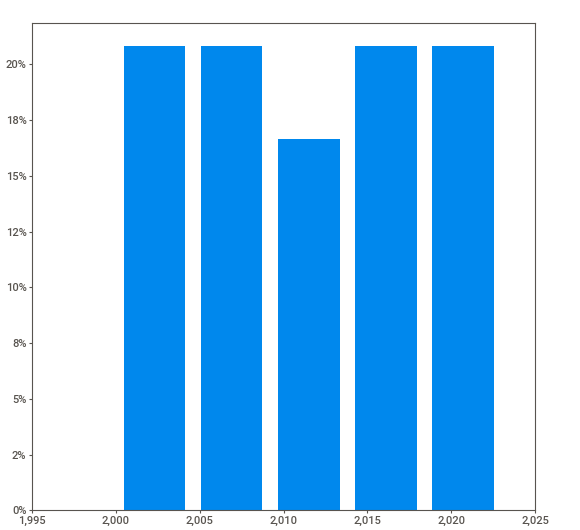
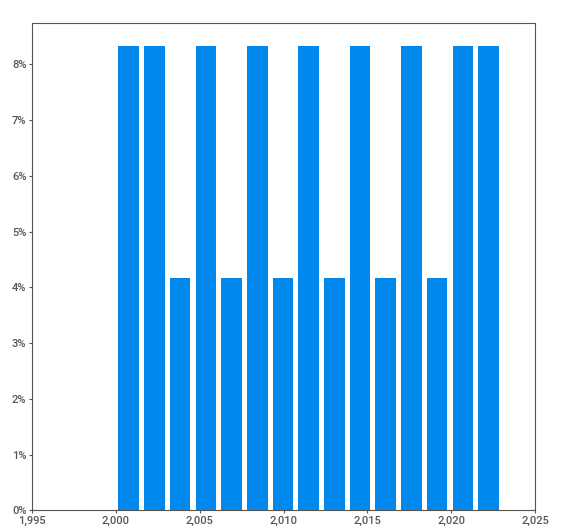
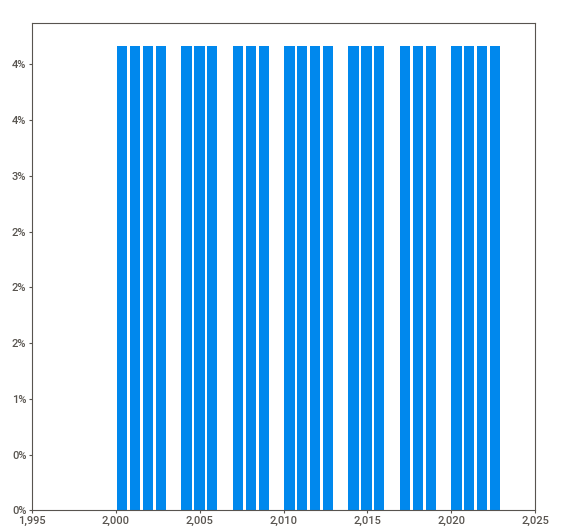
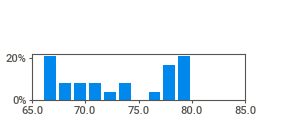
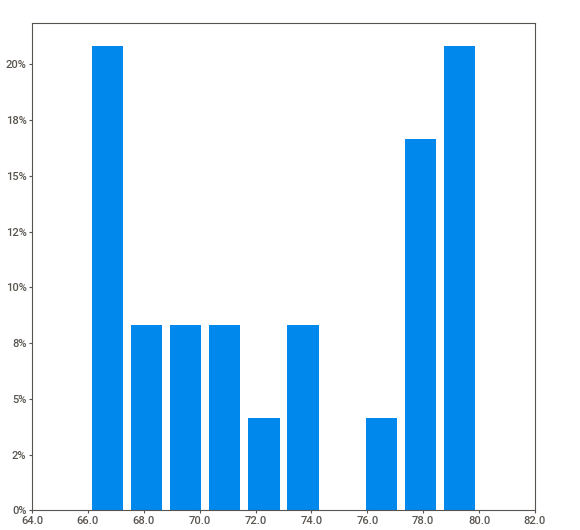
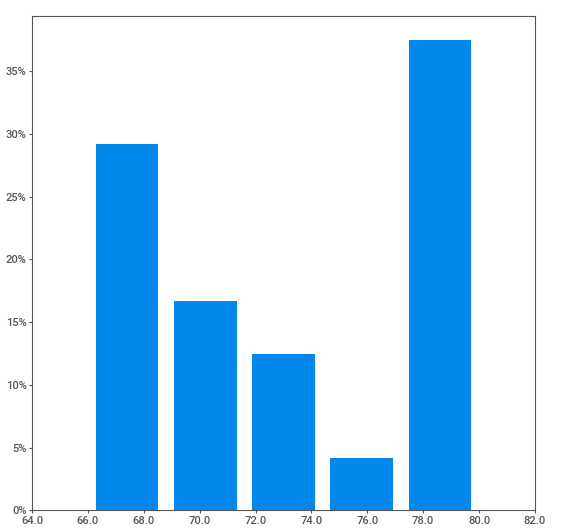
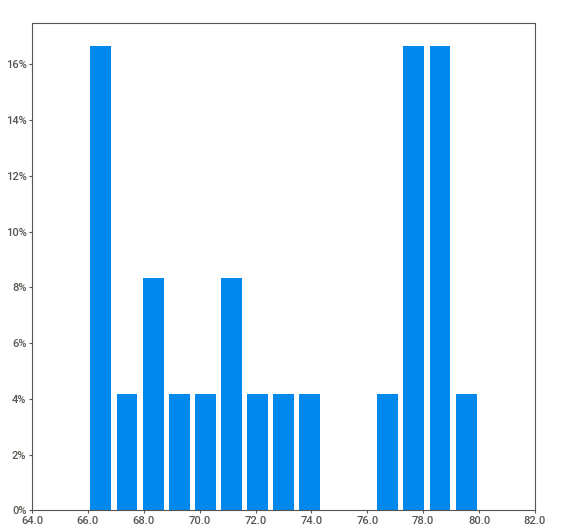
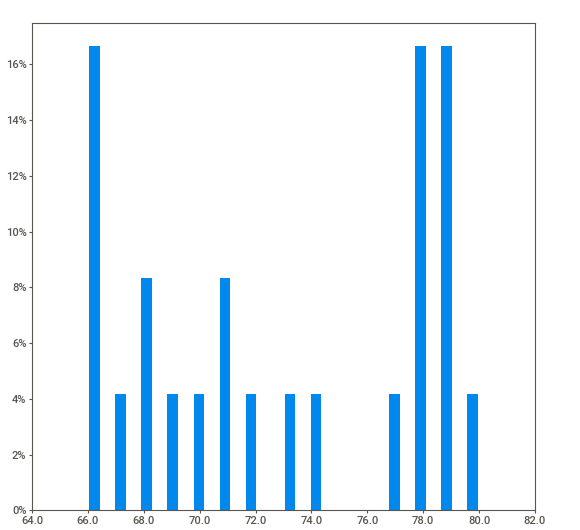
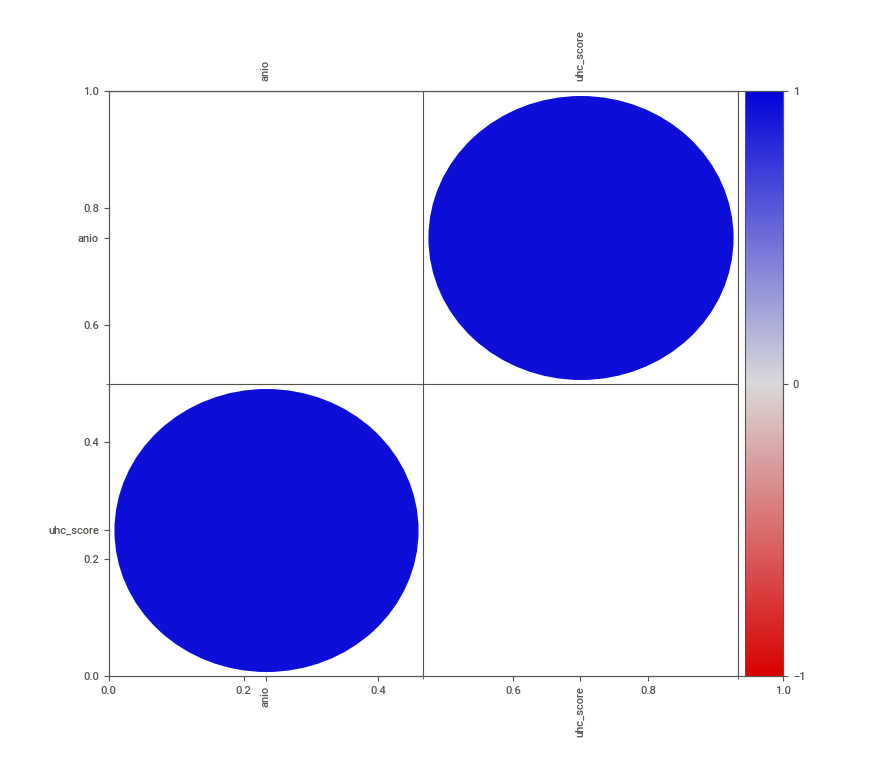
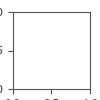

In [8]:
#Reporte 3: uhc_index_ecuador
rep_uhc = sv.analyze(df_uhc)
rep_uhc.show_html(ruta + "sweetviz_uhc.html", open_browser=False)
print("Reporte tf_uhc guardado en Drive")
rep_uhc.show_notebook()

---
##Analisis -> Variables de Dosis


In [9]:
dosis_cols = ["dosis_total", "primera_dosis", "segunda_dosis",
              "dosis_unica", "dosis_refuerzo"]

# Estadisticas descriptivas
print("\n Estadisticas descriptivas — variables de dosis")
print(df_fact[dosis_cols].describe().applymap(lambda x: f"{x:,.0f}"))


 Estadisticas descriptivas — variables de dosis
      dosis_total primera_dosis segunda_dosis dosis_unica dosis_refuerzo
count      66,320        66,320        66,320      66,320         66,320
mean       57,080        32,700        23,314         589            477
std       263,230       142,360       117,318       3,198          5,388
min             1             0             0           0              0
25%         2,777         2,040           554           0              0
50%        12,546         7,942         3,888           0              0
75%        39,195        23,158        15,134         180              0
max     4,956,326     2,337,173     2,283,263      61,994        286,080


##Analisis Temporal COVID-19

Visualizacion la evolución de muertes COVID en el tiempo.

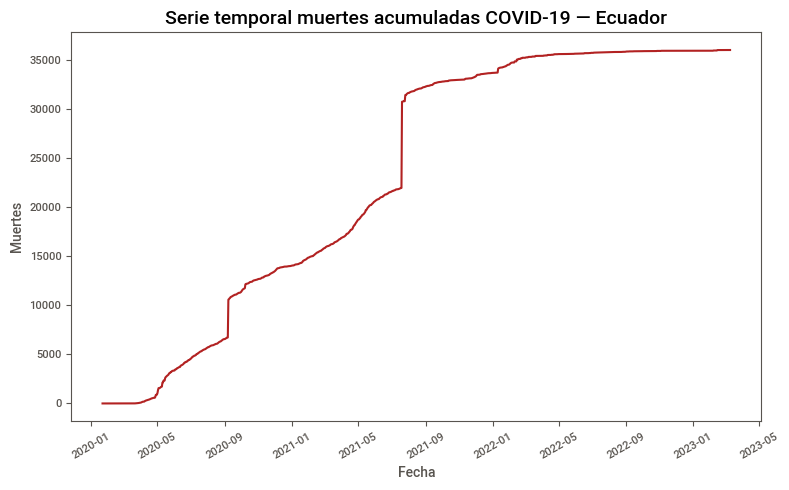

Serie temporal COVID guardada


In [10]:
df_cv = df_covid.copy()
df_cv["fecha"] = pd.to_datetime(df_cv["fecha"])

plt.figure(figsize=(8, 5))
plt.title("Serie temporal muertes acumuladas COVID-19 — Ecuador", fontsize=14, fontweight="bold")

# Muertes acumuladas
plt.plot(df_cv["fecha"], df_cv["muertes_acumuladas"],
         color="firebrick", linewidth=1.5)
plt.xticks(rotation=30)
plt.xlabel("Fecha")
plt.ylabel("Muertes")

plt.tight_layout()
plt.savefig(ruta + "eda_covid_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Serie temporal COVID guardada")

##Analisis Temporal -> Vacunación por Año

Evolución anual de dosis aplicadas, desagregadas por tipo.

In [11]:
# Análisis temporal por MES
# los datos de dosis son ACUMULATIVOS por cantón.

dosis_cols = ["dosis_total", "primera_dosis", "segunda_dosis", "dosis_unica", "dosis_refuerzo"]

df_fact_fecha = df_fact.merge(
    df_fecha_test[["id", "anio", "mes"]],
    left_on="date_id", right_on="id", how="left"
)

#acumulado maximo por cantón y mes
cum_canton_mes = (
    df_fact_fecha
    .groupby(["anio", "mes", "canton_id"])[dosis_cols]
    .max()
    .reset_index()
)

#suma nacional acumulada por mes
cum_nacional = (
    cum_canton_mes
    .groupby(["anio", "mes"])[dosis_cols]
    .sum()
    .reset_index()
    .sort_values(["anio", "mes"])
    .reset_index(drop=True)
)

#dosis nuevas del mes = diferencia entre meses consecutivos
dosis_mensual = cum_nacional.copy()
for col in dosis_cols:
    dosis_mensual[col] = cum_nacional[col].diff()
    dosis_mensual.iloc[0, dosis_mensual.columns.get_loc(col)] = cum_nacional.iloc[0][col]


dosis_mensual["periodo"] = (dosis_mensual["anio"].astype(str) + "-" +
                             dosis_mensual["mes"].astype(str).str.zfill(2))

print(f"Meses disponibles: {len(dosis_mensual)}")
print(dosis_mensual[["periodo","dosis_total"]].to_string(index=False))


Meses disponibles: 12
periodo  dosis_total
2021-01       7133.0
2021-02      69412.0
2021-03     390819.0
2021-04    1029162.0
2021-05    1387885.0
2021-06    1916189.0
2021-07    7622728.0
2021-08    6946277.0
2021-09    1465054.0
2021-10    1733306.0
2021-11    2600900.0
2021-12    2362820.0


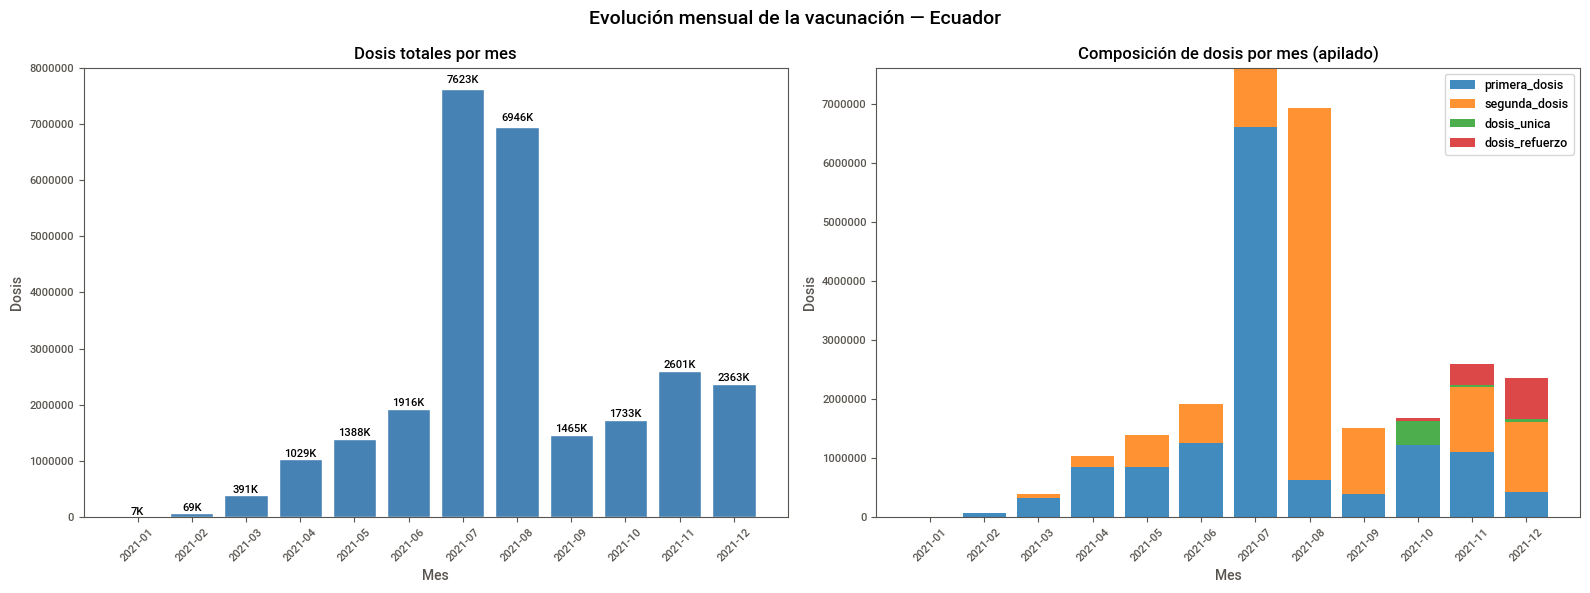

Gráfico mensual guardado


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Evolución mensual de la vacunación — Ecuador",
             fontsize=14, fontweight="bold")

# Dosis totales por mes
bars = axes[0].bar(dosis_mensual["periodo"], dosis_mensual["dosis_total"],
                   color="steelblue", edgecolor="white")
axes[0].set_title("Dosis totales por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Dosis")
axes[0].tick_params(axis="x", rotation=45)
for bar, val in zip(bars, dosis_mensual["dosis_total"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height()*1.01,
                 f"{val/1e3:.0f}K", ha="center", va="bottom", fontsize=8)

# Composición por mes (apilado)
tipo_cols  = ["primera_dosis","segunda_dosis","dosis_unica","dosis_refuerzo"]
colors_stk = ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]
bottom = np.zeros(len(dosis_mensual))
for col, color in zip(tipo_cols, colors_stk):
    axes[1].bar(dosis_mensual["periodo"], dosis_mensual[col],
                bottom=bottom, label=col, color=color, alpha=0.85)
    bottom += dosis_mensual[col].values
axes[1].set_title("Composición de dosis por mes (apilado)")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Dosis")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(ruta + "eda_dosis_mensual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico mensual guardado")

> **Observaciones:**
> -La gran mayoria de las personas que se vacunaron recibieron primera y segunda dosis, una cantidad casi insignificante recibio dosis unica o dosis de refuerzo.

---
##UHC Score - Evolucion del indice

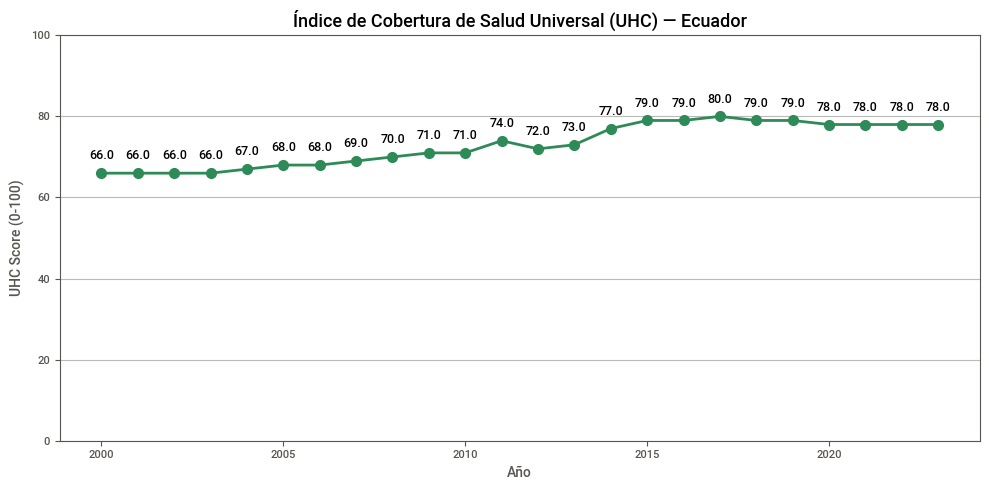

Gráfico UHC Score guardado

Último año disponible: 2023
Último UHC Score: 78.0
Tendencia: variable


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_uhc["anio"], df_uhc["uhc_score"],
        marker="o", color="seagreen", linewidth=2, markersize=7)

# Añadir etiquetas de valor
for _, row in df_uhc.iterrows():
    ax.annotate(f"{row['uhc_score']:.1f}",
                (row["anio"], row["uhc_score"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9)

ax.set_title("Índice de Cobertura de Salud Universal (UHC) — Ecuador",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("UHC Score (0-100)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(ruta + "eda_uhc_score.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico UHC Score guardado")

print(f"\nÚltimo año disponible: {df_uhc['anio'].max()}")
print(f"Último UHC Score: {df_uhc.loc[df_uhc['anio'].idxmax(), 'uhc_score']:.1f}")
print(f"Tendencia: {'creciente ↑' if df_uhc['uhc_score'].is_monotonic_increasing else 'variable'}")

## Analisis de distribucion y boxplots


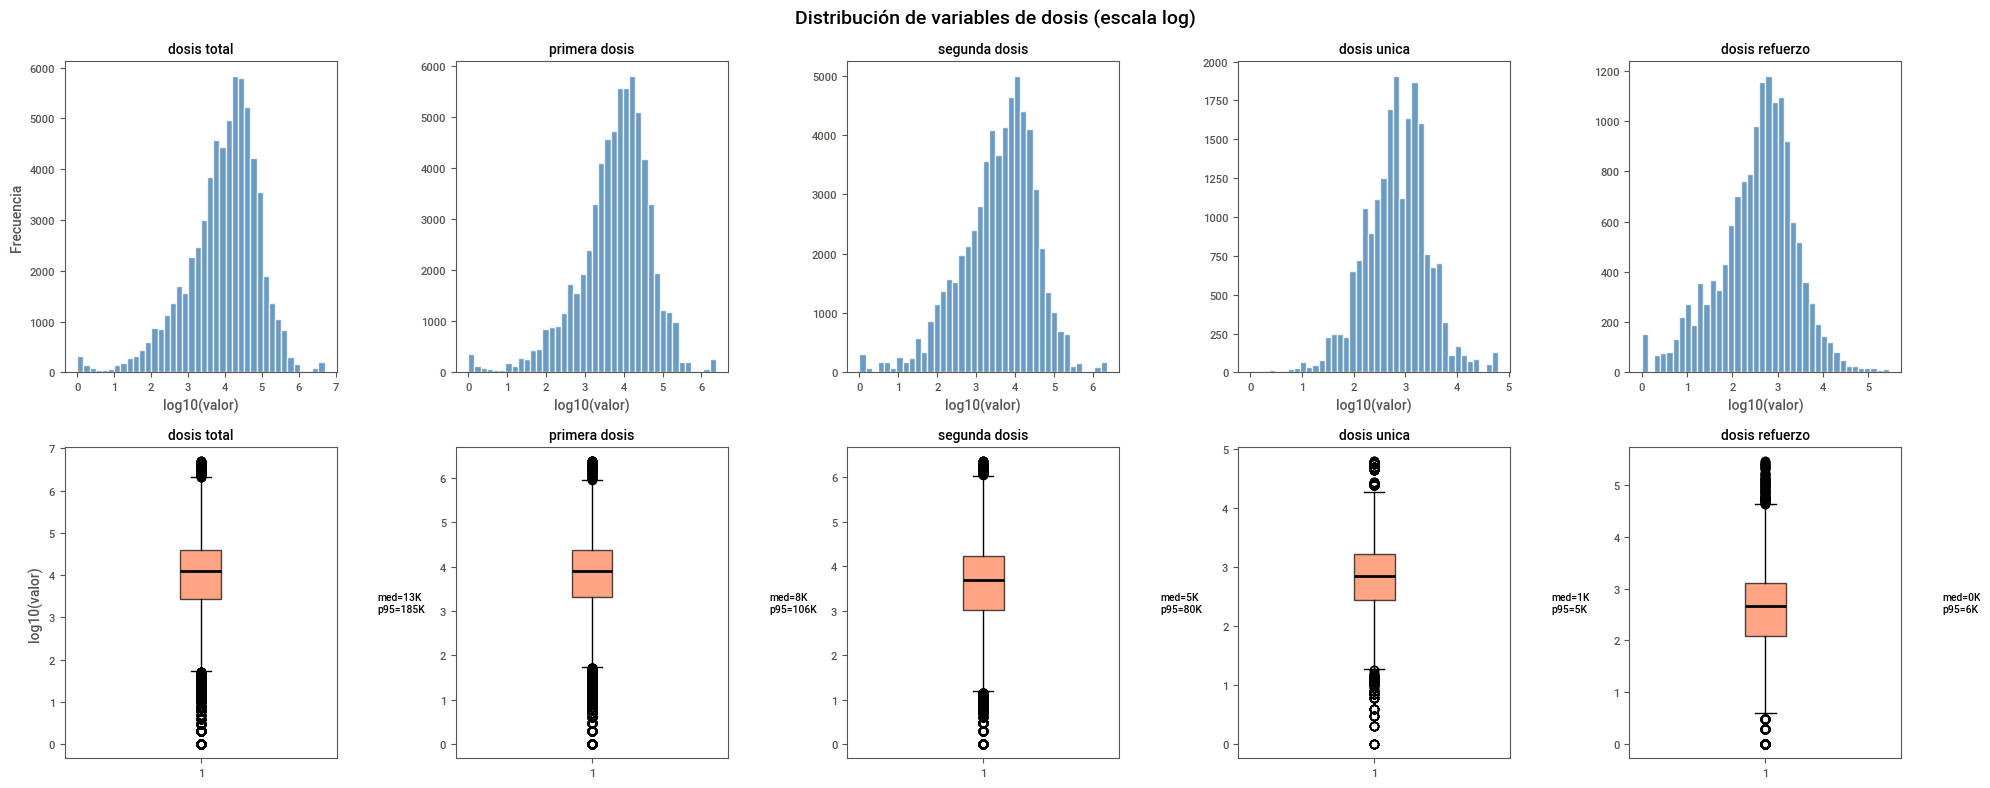

Distribuciones guardadas ✓


In [14]:
dosis_cols = ["dosis_total","primera_dosis","segunda_dosis","dosis_unica","dosis_refuerzo"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Distribución de variables de dosis (escala log)",
             fontsize=14, fontweight="bold")

for i, col in enumerate(dosis_cols):
    serie = df_fact[col][df_fact[col] > 0]  # log requiere > 0

    # Histograma log
    axes[0, i].hist(np.log10(serie), bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(col.replace("_", " "), fontsize=10)
    axes[0, i].set_xlabel("log10(valor)")
    axes[0, i].set_ylabel("Frecuencia" if i == 0 else "")

    # Boxplot log
    axes[1, i].boxplot(np.log10(serie), patch_artist=True,
                       boxprops=dict(facecolor="coral", alpha=0.7),
                       medianprops=dict(color="black", linewidth=2))
    axes[1, i].set_title(col.replace("_", " "), fontsize=10)
    axes[1, i].set_ylabel("log10(valor)" if i == 0 else "")

    # Anotar mediana y p95
    med = serie.median()
    p95 = serie.quantile(0.95)
    axes[1, i].annotate(f"med={med/1e3:.0f}K\np95={p95/1e3:.0f}K",
                        xy=(1.15, 0.5), xycoords="axes fraction",
                        fontsize=7.5, va="center")

plt.tight_layout()
plt.savefig(ruta + "eda_distribuciones_dosis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Distribuciones guardadas ✓")


> **Observación:** Todas las variables de dosis muestran distribución log-normal con cola derecha larga. Los cantones más grandes (Guayaquil, Quito) generan los valores extremos. La mediana es representativa del cantón típico.

## Desglose geografico por provincia y region

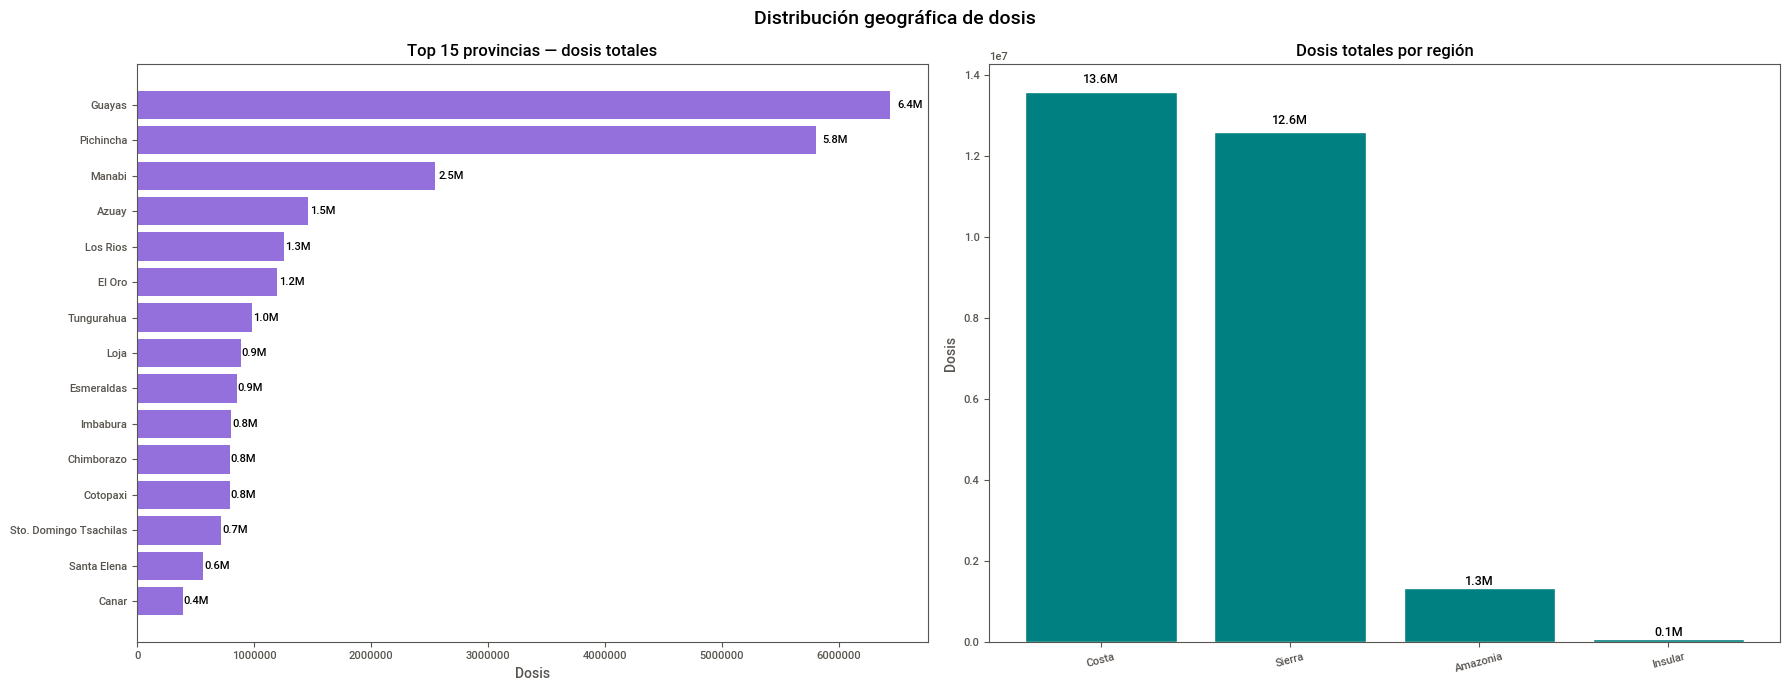

Desglose geográfico guardado

Provincias en el dataset : 24
Cantones en el dataset   : 219
Regiones en el dataset   : 4


In [15]:
# Cargar dimensiones
df_canton   = pd.read_csv(ruta + "tf_canton.csv")
df_provincia= pd.read_csv(ruta + "tf_provincia.csv")
df_region   = pd.read_csv(ruta + "tf_region.csv")
df_fecha    = pd.read_csv(ruta + "tf_fecha.csv")

# Enriquecer df_fact con dimensiones geograficas
df_geo = df_fact.merge(df_canton[["canton_id","canton_nombre"]],    on="canton_id",    how="left") \
                .merge(df_provincia[["id","provincia_nombre"]],      left_on="provincia_id", right_on="id", how="left") \
                .merge(df_region[["id","region_nombre"]],            left_on="region_id",    right_on="id", how="left",
                       suffixes=("","_reg"))

# Por provincia (top 15)
dosis_prov = (
    df_geo.groupby(["provincia_nombre", "canton_id"])["dosis_total"].max()
    .reset_index()
    .groupby("provincia_nombre")["dosis_total"].sum()
    .sort_values(ascending=False)
    .head(15)
)

# Por región
dosis_reg = (
    df_geo.groupby(["region_nombre", "canton_id"])["dosis_total"].max()
    .reset_index()
    .groupby("region_nombre")["dosis_total"].sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Distribución geográfica de dosis", fontsize=14, fontweight="bold")

# Provincias
axes[0].barh(dosis_prov.index[::-1], dosis_prov.values[::-1], color="mediumpurple")
axes[0].set_title("Top 15 provincias — dosis totales")
axes[0].set_xlabel("Dosis")
for i, val in enumerate(dosis_prov.values[::-1]):
    axes[0].text(val * 1.01, i, f"{val/1e6:.1f}M", va="center", fontsize=8)

# Regiones
bars_reg = axes[1].bar(dosis_reg.index, dosis_reg.values, color="teal", edgecolor="white")
axes[1].set_title("Dosis totales por región")
axes[1].set_ylabel("Dosis")
axes[1].tick_params(axis="x", rotation=15)
for bar, val in zip(bars_reg, dosis_reg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                 f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(ruta + "eda_geo_provincia_region.png", dpi=150, bbox_inches="tight")
plt.show()
print("Desglose geográfico guardado")

print(f"\nProvincias en el dataset : {df_geo['provincia_nombre'].nunique()}")
print(f"Cantones en el dataset   : {df_geo['canton_nombre'].nunique()}")
print(f"Regiones en el dataset   : {df_geo['region_nombre'].nunique()}")

# ***Dashboard***

-Se hace el dashboard aparte para evitar conflictos entre las versiones de las dependencias

In [18]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Ruta al DWH (mismo directorio compartido que los CSVs)
ruta_dwh_second_delivery = ruta + "vacunacion_ecuador_dw_second_delivery.db"
conn = sqlite3.connect(ruta_dwh_second_delivery)

# Verificar tablas
tablas = pd.read_sql('SELECT name FROM sqlite_master WHERE type="table"', conn)
print("Tablas en el DWH:")
for t in tablas["name"]:
    n = pd.read_sql(f"SELECT COUNT(*) as n FROM {t}", conn).iloc[0, 0]
    print(f"  {t:<42} {n:>8,} filas")

SQL_MENSUAL = """
WITH max_canton_mes AS (
    SELECT d.anio, d.mes, f.canton_id,
           MAX(f.dosis_total)    AS dt, MAX(f.primera_dosis)  AS pd,
           MAX(f.segunda_dosis)  AS sd, MAX(f.dosis_unica)    AS du,
           MAX(f.dosis_refuerzo) AS dr
    FROM fact_vacunacion f
    JOIN dim_fecha d ON f.date_id = d.id
    GROUP BY d.anio, d.mes, f.canton_id
),
acum AS (
    SELECT anio, mes,
           SUM(dt) AS dt_a, SUM(pd) AS pd_a,
           SUM(sd) AS sd_a, SUM(du) AS du_a, SUM(dr) AS dr_a
    FROM max_canton_mes
    GROUP BY anio, mes
)
SELECT anio, mes,
       dt_a - LAG(dt_a, 1, 0) OVER (ORDER BY anio, mes) AS dosis_total,
       pd_a - LAG(pd_a, 1, 0) OVER (ORDER BY anio, mes) AS primera_dosis,
       sd_a - LAG(sd_a, 1, 0) OVER (ORDER BY anio, mes) AS segunda_dosis,
       du_a - LAG(du_a, 1, 0) OVER (ORDER BY anio, mes) AS dosis_unica,
       dr_a - LAG(dr_a, 1, 0) OVER (ORDER BY anio, mes) AS dosis_refuerzo
FROM acum
ORDER BY anio, mes
"""
df_m = pd.read_sql(SQL_MENSUAL, conn)
df_m["periodo"] = df_m["anio"].astype(str) + "-" + df_m["mes"].astype(str).str.zfill(2)

#Top cantones / provincias / regiones
df_cant = pd.read_sql("""
    SELECT c.canton_nombre, MAX(f.dosis_total) AS total
    FROM fact_vacunacion f
    JOIN dim_canton c ON f.canton_id = c.canton_id
    GROUP BY c.canton_nombre
    ORDER BY total DESC LIMIT 10
""", conn)

df_prov = pd.read_sql("""
    SELECT p.provincia_nombre, SUM(canton_max) AS total
    FROM (
        SELECT canton_id, MAX(dosis_total) AS canton_max, MAX(provincia_id) AS provincia_id
        FROM fact_vacunacion GROUP BY canton_id
    ) sub
    JOIN dim_provincia p ON sub.provincia_id = p.id
    GROUP BY p.provincia_nombre
    ORDER BY total DESC LIMIT 10
""", conn)

df_reg = pd.read_sql("""
    SELECT r.region_nombre, SUM(canton_max) AS total
    FROM (
        SELECT canton_id, MAX(dosis_total) AS canton_max, MAX(region_id) AS region_id
        FROM fact_vacunacion GROUP BY canton_id
    ) sub
    JOIN dim_region r ON sub.region_id = r.id
    GROUP BY r.region_nombre
    ORDER BY total DESC
""", conn)

# Muertes COVID 2021
df_covid21 = pd.read_sql("""
    SELECT d.mes, SUM(f.muertes_diarias) AS muertes
    FROM fact_decesos f
    JOIN dim_fecha d ON f.date_id = d.id
    WHERE d.anio = 2021
    GROUP BY d.mes
    ORDER BY d.mes
""", conn)

#Cobertura vacunacion por canton
df_cob = pd.read_sql("""
    SELECT c.canton_nombre,
           ROUND(100.0 * MAX(f.dosis_total) / MAX(f.poblacion_canton), 1) AS cobertura_pct
    FROM fact_vacunacion f
    JOIN dim_canton c ON f.canton_id = c.canton_id
    WHERE f.poblacion_canton > 0
    GROUP BY c.canton_nombre
    ORDER BY cobertura_pct DESC LIMIT 10
""", conn)

# historico UHC
df_uhc_hist = pd.read_sql("SELECT anio, uhc_score FROM dim_indice_uhc ORDER BY anio", conn)

# Dosis anuales por tipo
df_anual = pd.read_csv(ruta + "tf_merged.csv")[
    ["anio", "dosis_total", "primera_dosis", "segunda_dosis",
     "dosis_unica", "dosis_refuerzo"]
].sort_values("anio").reset_index(drop=True)

print(f"\nMeses cargados : {len(df_m)}")
print(f"Anios anuales  : {list(df_anual['anio'])}")
#print(f"Total nacional : {df_cant['total'].sum():,.0f} dosis")
print(f"Suma top-10 cantones : {df_cant['total'].sum():,.0f} dosis")
total_nacional = df_reg['total'].sum()
print(f"Total nacional       : {total_nacional:,.0f} dosis")


Tablas en el DWH:
  sqlite_sequence                                   1 filas
  dim_fecha                                       346 filas
  dim_canton                                      221 filas
  dim_provincia                                    24 filas
  dim_region                                        4 filas
  dim_indice_uhc                                   24 filas
  fact_vacunacion                              66,320 filas
  fact_decesos                                    346 filas

Meses cargados : 12
Anios anuales  : [2021]
Suma top-10 cantones : 13,895,510 dosis
Total nacional       : 27,531,685 dosis


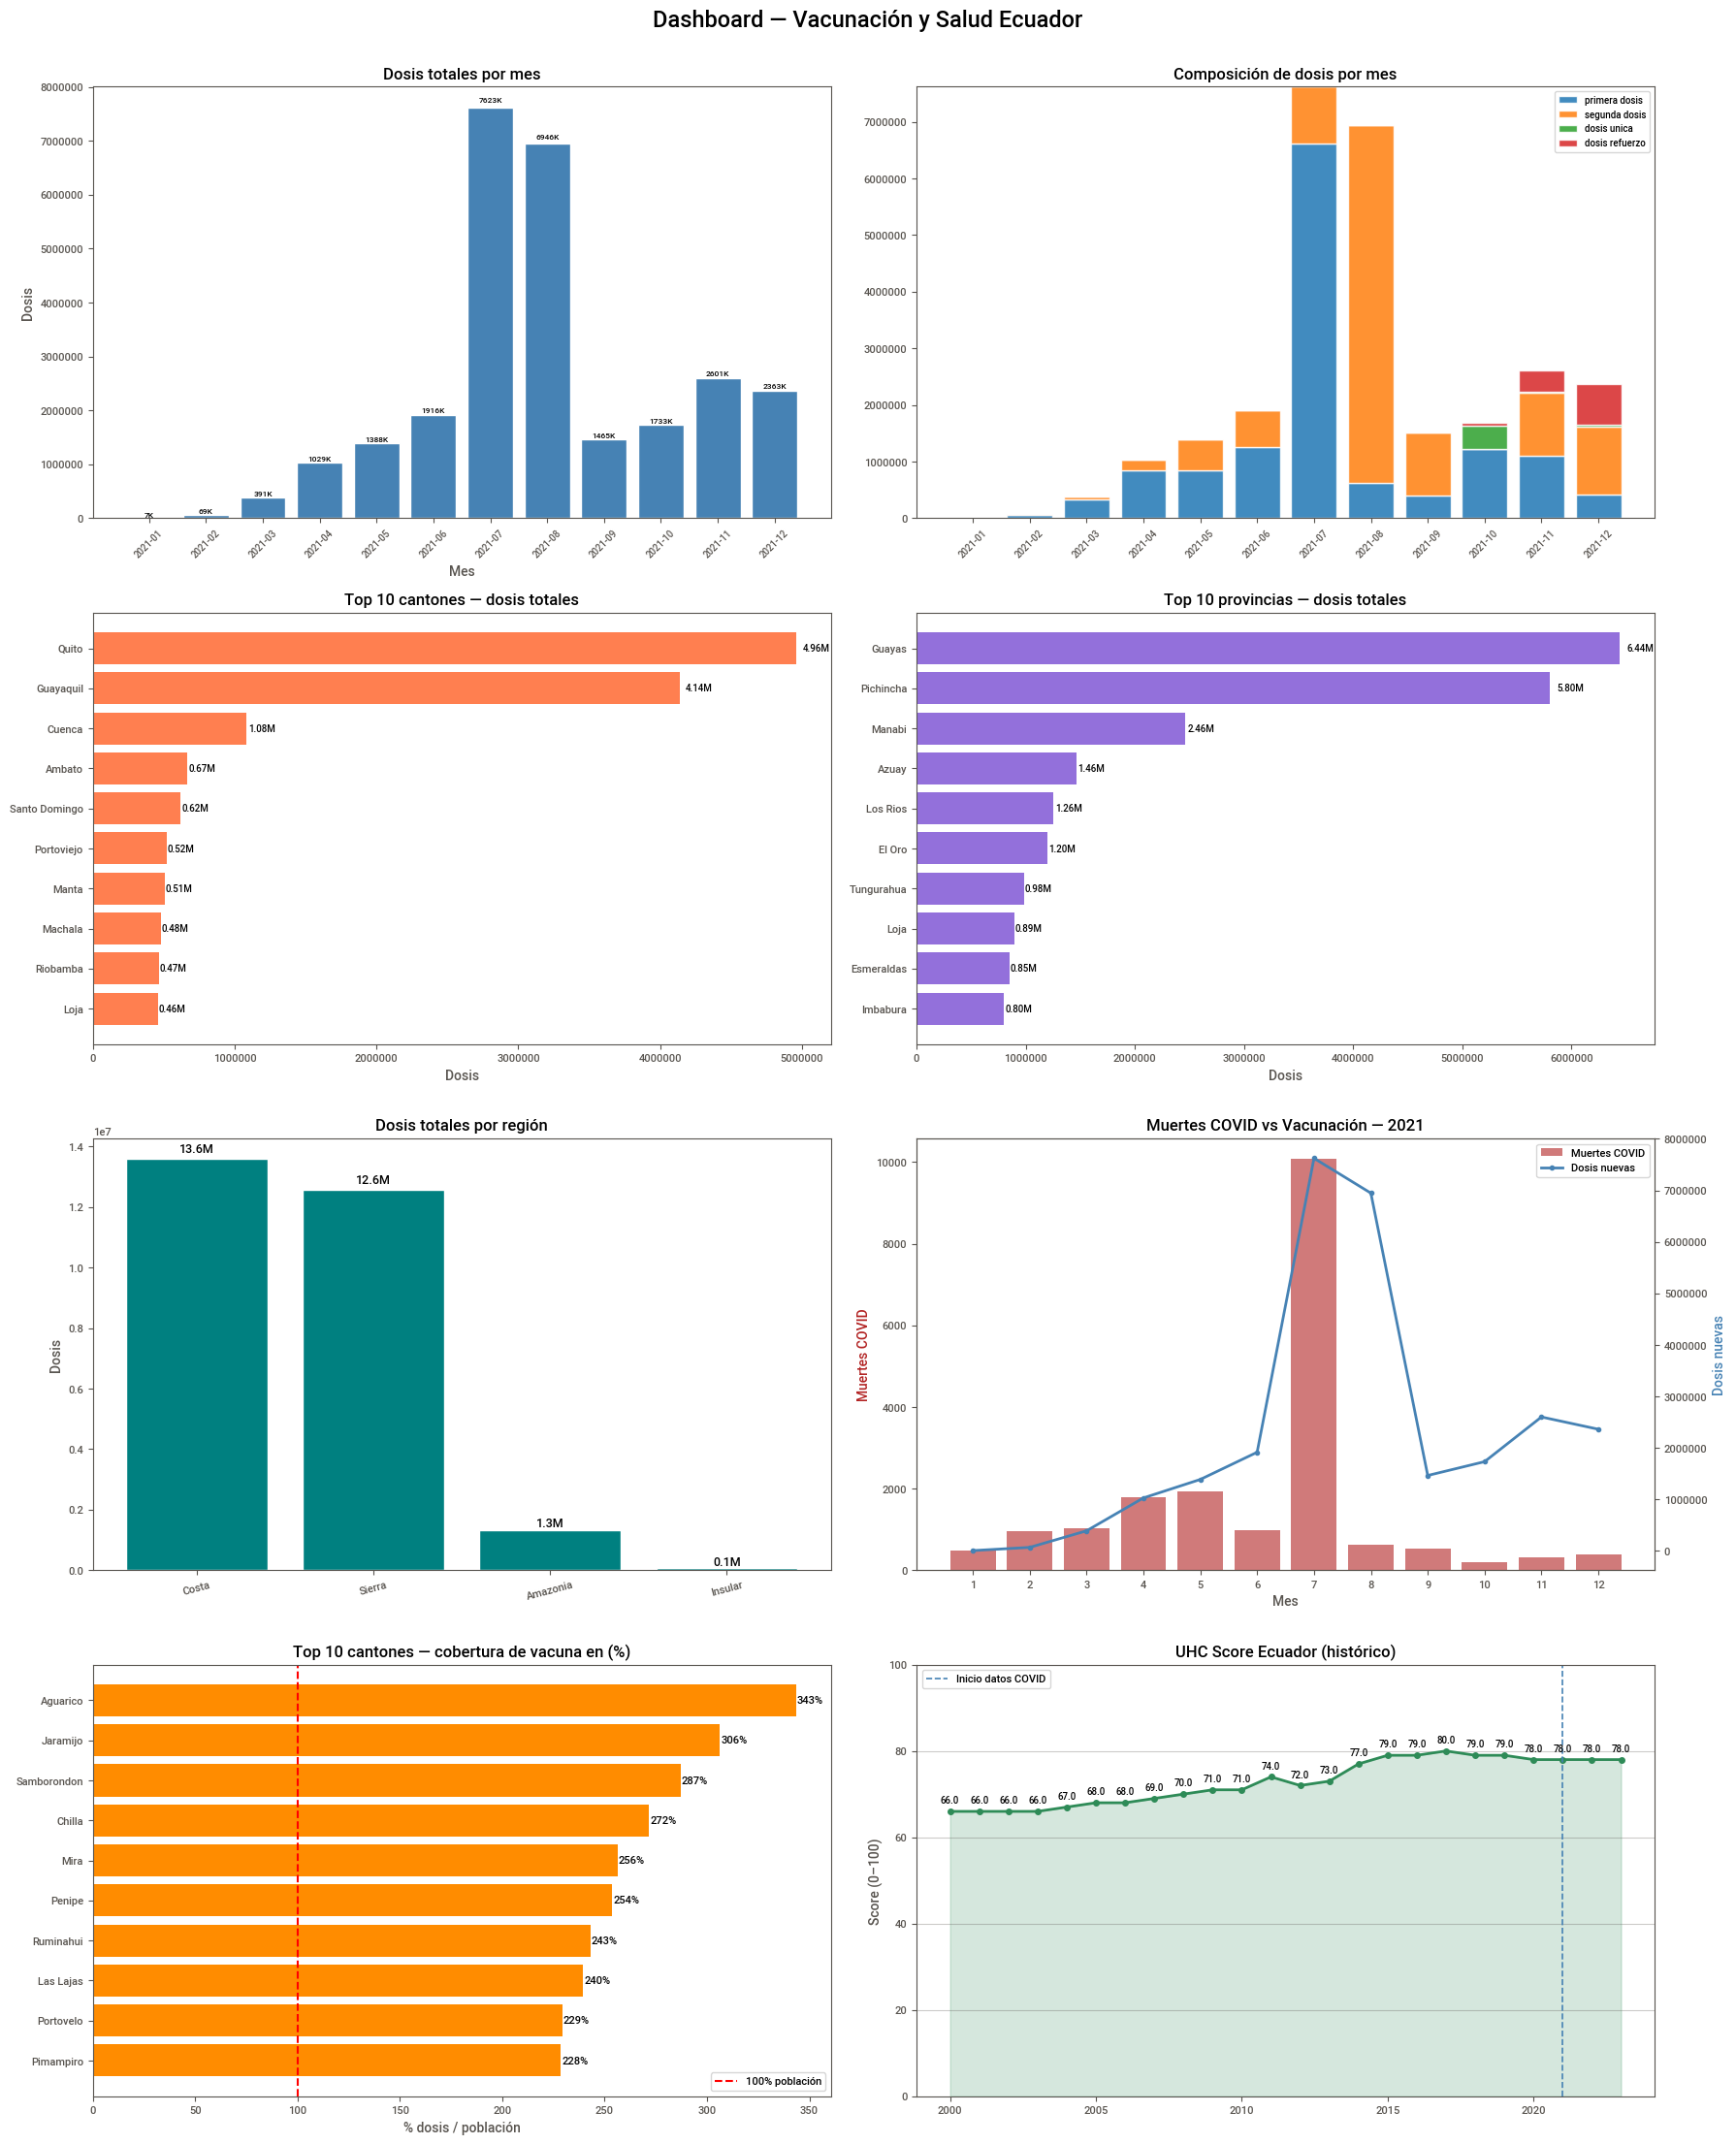

Dashboard (8 gráficos) guardado en Drive


In [17]:
fig = plt.figure(figsize=(18, 22))
fig.suptitle("Dashboard — Vacunación y Salud Ecuador",
             fontsize=17, fontweight="bold", y=1.003)

#1) Evolución mensual dosis totales
ax1 = fig.add_subplot(4, 2, 1)
bars = ax1.bar(df_m["periodo"], df_m["dosis_total"],
               color="steelblue", edgecolor="white")
ax1.set_title("Dosis totales por mes")
ax1.set_xlabel("Mes")
ax1.set_ylabel("Dosis")
ax1.tick_params(axis="x", rotation=45, labelsize=7)
for bar, val in zip(bars, df_m["dosis_total"]):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                 f"{val/1e3:.0f}K", ha="center", va="bottom", fontsize=6)

#2) Composición dosis por mes (apilado)
ax2 = fig.add_subplot(4, 2, 2)
tipo_cols  = ["primera_dosis", "segunda_dosis", "dosis_unica", "dosis_refuerzo"]
colors_stk = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
bottom = np.zeros(len(df_m))
for col, color in zip(tipo_cols, colors_stk):
    ax2.bar(df_m["periodo"], df_m[col], bottom=bottom,
            label=col.replace("_", " "), color=color, alpha=0.85, edgecolor="white")
    bottom += df_m[col].fillna(0).values
ax2.set_title("Composición de dosis por mes")
ax2.tick_params(axis="x", rotation=45, labelsize=7)
ax2.legend(fontsize=7)

#3) Top 10 cantones ─
ax3 = fig.add_subplot(4, 2, 3)
ax3.barh(df_cant["canton_nombre"][::-1], df_cant["total"][::-1], color="coral")
ax3.set_title("Top 10 cantones — dosis totales")
ax3.set_xlabel("Dosis")
for i, val in enumerate(df_cant["total"][::-1]):
    ax3.text(val * 1.01, i, f"{val/1e6:.2f}M", va="center", fontsize=7)

#4) Top 10 provincias
ax4 = fig.add_subplot(4, 2, 4)
ax4.barh(df_prov["provincia_nombre"][::-1], df_prov["total"][::-1], color="mediumpurple")
ax4.set_title("Top 10 provincias — dosis totales")
ax4.set_xlabel("Dosis")
for i, val in enumerate(df_prov["total"][::-1]):
    ax4.text(val * 1.01, i, f"{val/1e6:.2f}M", va="center", fontsize=7)

#5) Dosis por region
ax5 = fig.add_subplot(4, 2, 5)
bars5 = ax5.bar(df_reg["region_nombre"], df_reg["total"],
                color="teal", edgecolor="white")
ax5.set_title("Dosis totales por región")
ax5.set_ylabel("Dosis")
ax5.tick_params(axis="x", rotation=15)
for bar, val in zip(bars5, df_reg["total"]):
    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
             f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=9)

#6) Muertes COVID vs vacunacion 2021
#df_m filtrado a 2021 para alinear con los datos de COVID
ax6 = fig.add_subplot(4, 2, 6)
df_m21 = df_m[df_m["anio"] == 2021].copy()
ax6b = ax6.twinx()
ax6.bar(df_covid21["mes"], df_covid21["muertes"],
        color="firebrick", alpha=0.6, label="Muertes COVID")
ax6b.plot(df_m21["mes"], df_m21["dosis_total"],
          color="steelblue", marker="o", linewidth=2, label="Dosis nuevas")
ax6.set_title("Muertes COVID vs Vacunación — 2021")
ax6.set_xlabel("Mes")
ax6.set_ylabel("Muertes COVID", color="firebrick")
ax6b.set_ylabel("Dosis nuevas", color="steelblue")
ax6.set_xticks(range(1, 13))
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

#7) Cobertura vacunacion top 10 cantones
ax7 = fig.add_subplot(4, 2, 7)
ax7.barh(df_cob["canton_nombre"][::-1], df_cob["cobertura_pct"][::-1],
         color="darkorange")
ax7.axvline(x=100, color="red", linestyle="--", linewidth=1.5, label="100% población")
ax7.set_title("Top 10 cantones — cobertura de vacuna en (%)")
ax7.set_xlabel("% dosis / población")
ax7.legend(fontsize=8)
for i, val in enumerate(df_cob["cobertura_pct"][::-1]):
    ax7.text(val + 0.5, i, f"{val:.0f}%", va="center", fontsize=8)

#8) UHC Score historico
ax8 = fig.add_subplot(4, 2, 8)
ax8.fill_between(df_uhc_hist["anio"], df_uhc_hist["uhc_score"],
                 alpha=0.2, color="seagreen")
ax8.plot(df_uhc_hist["anio"], df_uhc_hist["uhc_score"],
         marker="o", color="seagreen", linewidth=2, markersize=4)
for _, row in df_uhc_hist.iterrows():
    ax8.annotate(f"{row['uhc_score']:.1f}",
                 (row["anio"], row["uhc_score"]),
                 textcoords="offset points", xytext=(0, 6),
                 ha="center", fontsize=7)
ax8.axvline(x=2021, color="steelblue", linestyle="--", linewidth=1.2,
            label="Inicio datos COVID")
ax8.set_title("UHC Score Ecuador (histórico)")
ax8.set_ylabel("Score (0–100)")
ax8.set_ylim(0, 100)
ax8.legend(fontsize=8)
ax8.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(ruta + "dashboard_vacunacion_ecuador.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard (8 gráficos) guardado en Drive")
